# Lab 02：異常偵測、模型與告警

Lab 01 留下一組 feature 與一份 spec。這一節把 feature 變成 score、score 變成決策、決策變成 alert，最後量這一整套值不值得交給值班人員。

三層要分清楚，因為損害發生在不同層，修的地方也不同：

| 層 | 是什麼 | 對「要不要通知人」的立場 |
|---|---|---|
| **score** | 連續數值，與正常狀態的距離 | 沒有立場 |
| **label** | score 跨過 threshold 並且持續了一段時間 | 統計上確認了，還沒決定通知誰 |
| **alert** | 通過維運過濾條件後真的送到人手上的那一部分 | 這一層才決定 |

本節是課程 pipeline 的第 8 格，也就是異常偵測模型、Dashboard 與 Alert Rule。前九步走完統計 baseline 這條路並且量出它的邊界，第 10 到 13 步換一種計分方式越過那道邊界，第 14 步之後回到告警與評估，那一段與計分方式無關。

| 步驟 | 做什麼 |
|---|---|
| 1 | 載入 feature、spec 與 ground truth |
| 2 | 四種 baseline，同一個 event 四種讀法 |
| 3 | 四種 baseline 的命中與代價 |
| 4 | robust 統計的 breakdown point |
| 5 | threshold 4.0 不是單純的 tail probability |
| 6 | CUSUM：累積偏差 |
| 7 | EWMA：指數加權 |
| 8 | change-point detection：水位移動了嗎 |
| 9 | degenerate 的欄位：統計不是工具的時候 |
| 10 | 逐欄計分的天花板：max 這個合成方式 |
| 11 | Isolation Forest |
| 12 | One-Class SVM 與 Local Outlier Factor |
| 13 | 四種偵測器，同一張成績單 |
| 14 | 多 feature 合成 score_max |
| 15 | score 到決策：連續 N 筆 confirmation |
| 16 | 決策到通知：alert policy |
| 17 | scorecard：event recall，不是 point accuracy |
| 18 | precision-recall 與 ROC |
| 19 | threshold × N 的二維 sweep |
| 20 | cost function：threshold 是商業決策 |
| 21 | 時間 holdout 與 confidence interval |
| 22 | weak label 下的評估偏差 |


## 這本 notebook 怎麼讀

先完成 Lab 01，因為這裡第一格就要讀它寫出來的 `features.csv`、`feature_spec.json` 與 `detection_ledger.csv`。從上往下逐格執行，整本重新執行一次大約 2 到 3 分鐘。

從第 2 步開始，每一個偵測方法都長成同一個三段式：

```python
def some_method(...):        # 1. the method is a function that only produces a score
    ...

det = rollout("name", some_method(...), tel, threshold=THRESHOLD)   # 2. one line to run it
plot_detection(det, tel, event_id="C")                              # 3. one line to see it
```

`rollout()` 把分數變成告警並且打分數，`plot_detection()` 畫出固定的三格圖：**左邊是訊號與紅色的告警點，中間是分數與門檻，右邊是全月成績單**。先看左圖，紅點該落在橘色的真實 event 上，落在外面就是誤報。

圖上不標 A、B、C，因為 event 本身就叫 A 到 J，兩套代號混在一起會讀錯。要指某一格就說位置。

每呼叫一次 `rollout()`，成績就進 ledger。Lab 01 已經放了四個方法進去，這本再往上加十幾個，結尾的 `plot_ledger()` 把它們畫在同一個「抓到幾個」對「每天幾筆」的平面上。判讀方式只有一條：**新方法要往左上方移動才算有貢獻**，落在舊方法的正右方或正下方就是白做。

三個層次在這本 notebook 裡從頭到尾分開，因為壞掉的地方不同、修的地方也不同：

| 層 | 是什麼 | 對「要不要通知人」的立場 |
|---|---|---|
| **score** | 連續數值，與正常狀態的距離 | 沒有立場 |
| **label** | score 跨過門檻並且連續 N 筆 | 統計上確認了，還沒決定通知誰 |
| **alert** | 通過維運過濾條件後真的送到人手上的 | 這一層才決定 |

第 2 到 13 步做的都是第一層，第 14 步之後才進到第二層與第三層。

In [1]:
from pathlib import Path
from collections import namedtuple
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import matplotlib.font_manager as fm

# Latin glyphs come from a serif face, CJK glyphs fall back to whatever this machine has.
# matplotlib walks this list per glyph, so one list covers both scripts on all three platforms.
_HAVE = {f.name for f in fm.fontManager.ttflist}
_LATIN = [f for f in ("Georgia", "Times New Roman", "DejaVu Serif") if f in _HAVE]
_CJK = [f for f in ("Heiti TC", "PingFang TC", "PingFang HK", "Songti TC", "LiHei Pro",
                    "Microsoft JhengHei", "Noto Sans CJK TC", "Source Han Sans TC",
                    "Arial Unicode MS", "WenQuanYi Zen Hei") if f in _HAVE]
if not _CJK:
    print("No CJK font found. Plot text is English, so this only matters if you add a "
          "Chinese label: macOS ships Heiti TC, Linux needs fonts-noto-cjk, "
          "Windows has Microsoft JhengHei.")

plt.rcParams.update({
    "font.family": (_LATIN + _CJK) or ["DejaVu Sans"],
    "axes.unicode_minus": False,          # the CJK faces have no U+2212, so use a plain hyphen
    "figure.dpi": 110, "axes.titlesize": 10, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "synthetic"
OUT = ROOT / "outputs" / "workshop"

C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}
MAD_TO_SIGMA = 1.4826
MAX_SCORE = 50.0

# The two knobs this whole notebook is about. Step 19 sweeps them jointly; every number
# before that is measured at these values, so changing them here changes the whole lab.
THRESHOLD = 4.0
N_CONSEC = 2

# Comparing detectors on different scales needs a common currency. BUDGET is that currency:
# the share of samples a detector is allowed to flag, so every method gets the same on-call bill.
BUDGET = 0.995


def floor_of(values, fraction=0.05):
    """Lower bound for any score denominator, at a fraction of the whole series' spread."""
    x = np.asarray(values, float)
    x = x[np.isfinite(x)]
    mad = float(np.median(np.abs(x - np.median(x)))) * MAD_TO_SIGMA
    if mad <= 0:
        mad = float(np.std(x)) or 0.01 * float(np.mean(np.abs(x))) or 1e-12
    return max(fraction * mad, 1e-12)


def z_of(v, center, scale):
    """Standardise to (value - center) / scale, with the floor applied and the result capped."""
    f = floor_of(v)
    return ((v - center) / scale.fillna(f).clip(lower=f)).clip(-MAX_SCORE, MAX_SCORE)


def rolling_mean(v, w):
    """Center and scale from the arithmetic mean and the standard deviation of the window."""
    mp = max(3, w // 3)                              # need a third of the window before reporting
    return v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()


def rolling_robust(v, w):
    """Center and scale from the median and the MAD, both order statistics.

    The median does not move until more than half the window is contaminated, which is
    exactly the failure mode that breaks the mean during a sustained event.
    """
    mp = max(3, w // 3)
    center = v.rolling(w, min_periods=mp).median()
    mad = (v - center).abs().rolling(w, min_periods=mp).median() * MAD_TO_SIGMA
    return center, mad


from collections import namedtuple

# One detector, fully evaluated. Every method in both labs ends up as one of these, which is
# what makes them comparable at all: same confirmation rule, same recall denominator, same
# definition of what a day of on-call costs.
Detection = namedtuple("Detection", "name score threshold label per_event card")

LEDGER_PATH = OUT / "detection_ledger.csv"


def runs_of(mask, gap_tolerance=0):
    """Contiguous True runs as (start, end) index pairs, merging runs separated by a short gap."""
    idx = np.flatnonzero(np.asarray(mask, bool))
    if idx.size == 0:
        return []
    split = np.flatnonzero(np.diff(idx) > gap_tolerance + 1)
    return list(zip(np.r_[idx[0], idx[split + 1]], np.r_[idx[split], idx[-1]]))


def rollout(name, score, frame, threshold=None, budget=None, n_consecutive=None, keep=True):
    """Score in, alerts and a scorecard out. This is the whole detection pipeline in one call.

    Three things happen, and they are the three layers this course keeps separate:
      1. threshold  a continuous score becomes a per-sample breach
      2. confirm    a breach becomes a label only if it repeats n_consecutive times in a row
      3. measure    labels are scored against ground truth as event recall and daily cost

    Give either `threshold` (an absolute cut, e.g. 4.0 on a z-score) or `budget` (a quantile
    of this detector's own score, e.g. 0.995). Two detectors on different scales can only be
    compared at equal budget, because their raw numbers do not mean the same thing.
    """
    n = N_CONSEC if n_consecutive is None else n_consecutive
    s = pd.Series(np.asarray(score, dtype=float), index=frame.index)
    if (threshold is None) == (budget is None):
        raise ValueError("rollout needs exactly one of threshold= or budget=")
    thr = float(np.nanquantile(s.dropna(), budget)) if threshold is None else float(threshold)

    breach = (s > thr).fillna(False)
    label = breach.copy()
    for k in range(1, n):                       # grouped, so a run never straddles two ports
        label &= breach.groupby(frame["port_id"]).shift(k).fillna(False)

    rows = []
    for e in INCIDENTS.itertuples():
        m = ((frame["port_id"] == e.port_id)
             & frame["timestamp"].between(e.start, e.end)).to_numpy()
        hit = label.to_numpy() & m
        first = frame.loc[hit, "timestamp"].min() if hit.any() else pd.NaT
        rows.append({"event_id": e.event_id, "event_type": e.event_type, "port_id": e.port_id,
                     "detected": bool(hit.any()),
                     "delay_min": ((first - e.start).total_seconds() / 60) if hit.any() else np.nan})
    per_event = pd.DataFrame(rows)

    inside = pd.Series(False, index=frame.index)
    for e in EVENTS.itertuples():               # planned changes count as neither hit nor cost
        inside |= (frame["port_id"] == e.port_id) & frame["timestamp"].between(e.start, e.end)
    days = (frame["timestamp"].max() - frame["timestamp"].min()).total_seconds() / 86400
    card = {"name": name, "threshold": round(thr, 4),
            "recall": int(per_event["detected"].sum()), "of": len(per_event),
            "labels_per_day": round(float((label & ~inside).sum()) / days, 2),
            "median_delay_min": float(per_event.loc[per_event["detected"], "delay_min"].median())
            if per_event["detected"].any() else np.nan,
            "caught_E": bool(per_event.loc[per_event["event_id"] == "E", "detected"].any())}

    det = Detection(name, s, thr, label, per_event, card)
    if keep:
        LEDGER[:] = [r for r in LEDGER if r["name"] != name] + [card]
    return det


def show_card(det):
    """The four numbers operations actually reads, printed the same way every time."""
    c = det.card
    print(f"{c['name']:<26} threshold {c['threshold']:>9.4g} | "
          f"recall {c['recall']:>2}/{c['of']} | {c['labels_per_day']:>7.2f} labels/day | "
          f"delay {c['median_delay_min']:>5.1f} min | event E {'✓' if c['caught_E'] else '✗'}")


def plot_detection(det, frame, event_id=None, col=None, pad="6h", title=None):
    """Three panels: where it fired, why it fired, and what that adds up to over the month.

    A is the one a beginner should read first. It is the measured signal with a dot on every
    sample the detector actually alerted on, so "did this method work" stops being a number
    and becomes something you can see against the shaded ground-truth window.
    """
    col = col or "traffic_bps"
    ev = (EVENTS[EVENTS.event_id == event_id].iloc[0] if event_id is not None
          else EVENTS.loc[EVENTS["n"].idxmax()])
    pad = pd.Timedelta(pad)
    idx = frame.index[frame["port_id"].eq(ev.port_id)
                      & frame["timestamp"].between(ev.start - pad, ev.end + pad)]
    w = frame.loc[idx]
    fired = det.label.loc[idx].to_numpy()
    inside = w["timestamp"].between(ev.start, ev.end).to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), gridspec_kw={"width_ratios": [1.5, 1.5, 1]})

    axes[0].plot(w["timestamp"], w[col], color=C["signal"], lw=1.0, label=col)
    axes[0].scatter(w.loc[fired, "timestamp"], w.loc[fired, col], s=26, color=C["alert"],
                    zorder=5, label=f"alerts fired ({int(fired.sum())})")
    axes[0].axvspan(ev.start, ev.end, color=C["truth"], alpha=0.3, lw=0, zorder=0,
                    label=f"labelled event {ev.event_id}")
    axes[0].set(ylabel=col, xlabel="time", title="where it fired, on the signal")
    axes[0].legend(fontsize=7, loc="upper left")
    axes[0].tick_params(axis="x", labelrotation=20)

    z = det.score.loc[idx]
    axes[1].plot(w["timestamp"], z, color=C["score"], lw=1.0, label="score")
    axes[1].axhline(det.threshold, color=C["alert"], ls="--", lw=1.2,
                    label=f"threshold {det.threshold:.3g}")
    for a, b in runs_of(fired):
        axes[1].axvspan(w["timestamp"].iloc[a], w["timestamp"].iloc[b], color=C["alert"],
                        alpha=0.18, lw=0)
    axes[1].axvspan(ev.start, ev.end, color=C["truth"], alpha=0.3, lw=0, zorder=0)
    axes[1].set(ylabel="score", xlabel="time", title=f"why it fired ({N_CONSEC} consecutive samples required)")
    axes[1].legend(fontsize=7, loc="upper left")
    axes[1].tick_params(axis="x", labelrotation=20)

    pe = det.per_event.sort_values(["detected", "delay_min"])
    axes[2].barh(range(len(pe)), [1] * len(pe),
                 color=[C["peer"] if d else C["alert"] for d in pe["detected"]], height=0.72)
    for k, t in enumerate(pe.itertuples()):
        axes[2].text(0.03, k, f"{t.event_id} {t.event_type[:15]}", va="center", fontsize=6.5,
                     color="white")
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    c = det.card
    axes[2].set_title(f"{c['recall']}/{c['of']} incidents caught over the month, "
                      f"{c['labels_per_day']:g} labels/day\ngreen caught, red missed", fontsize=9)
    fig.suptitle(title or f"{det.name}", y=1.04, fontsize=11)
    fig.tight_layout(); plt.show()
    show_card(det)


def plot_ledger(highlight=None, title="every method rolled out so far"):
    """Every rollout so far on one recall-against-cost plane. This is the contribution plot.

    A method earns its place by sitting up and to the left of the ones before it. A method
    that lands on top of an earlier one added nothing except another thing to maintain.

    Points carry numbers rather than names on purpose: a dozen methods cluster tightly in
    the cheap-and-accurate corner, and inline names there overlap into an unreadable smear.
    """
    if not LEDGER:
        print("ledger is empty"); return
    d = pd.DataFrame(LEDGER).reset_index(drop=True)
    d.index = d.index + 1
    fig, ax = plt.subplots(figsize=(11, 5.0))
    for n, t in d.iterrows():
        hi = (highlight is not None and t["name"] == highlight)
        x = max(t["labels_per_day"], 0.04)
        ax.scatter(x, t["recall"], s=210 if hi else 130,
                   color=C["alert"] if hi else (C["peer"] if t["caught_E"] else C["signal"]),
                   zorder=4 if hi else 3, edgecolors="white", linewidths=1.4)
        ax.text(x, t["recall"], str(n), ha="center", va="center", fontsize=7,
                color="white", zorder=5, fontweight="bold")
    ax.axhline(d["of"].max(), color=C["truth"], ls="--", lw=1.2,
               label=f"all {int(d['of'].max())} incidents")
    ax.scatter([], [], color=C["peer"], s=90, label="catches event E")
    ax.scatter([], [], color=C["signal"], s=90, label="misses event E")
    ax.set(xscale="log", xlabel="labels per day (quieter to the left, log)",
           ylabel="incident windows caught (higher is better)", title=title,
           ylim=(-1.0, d["of"].max() + 1.5))
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout(); plt.show()

    key = d[["name", "recall", "labels_per_day", "median_delay_min", "caught_E"]].copy()
    key.columns = ["method", "caught", "labels/day", "delay (min)", "event E"]
    display(key)
    return d

print(f"fonts  latin {_LATIN[:1]}  cjk {_CJK[:1]}")

fonts  latin ['Georgia']  cjk ['Heiti TC']


## 第 1 步：載入 feature、spec 與 ground truth

讀回 Lab 01 存的 `features.csv` 與 `feature_spec.json`。

spec 帶過來的是 Lab 01 量出來或決定的東西：cadence、window 長度、以及哪些欄位適用 z-score。在此之前這份名單是靠人抄的，Lab 01 改了界線這裡讀到的仍是舊值。現在它是讀進來的，不會再抄錯，改了界線這裡會跟著變。

ground truth 仍然不從 spec 帶過來，而是從 `event_label` 重建。recall 的分母應該由 ground truth 定義，不應該跟著任何設計檔一起漂。

In [2]:
feat_path = OUT / "features.csv"
spec_path = OUT / "feature_spec.json"
for p in (feat_path, spec_path):
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run Lab 01 to completion first.")

spec = json.loads(spec_path.read_text(encoding="utf-8"))
tel = pd.read_csv(feat_path, parse_dates=["timestamp"])
tel = tel.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

# Read from the spec rather than re-derived here, so a change to Lab 01 step 8 reaches
# this notebook instead of silently disagreeing with it.
CADENCE = spec["data_contract"]["cadence_seconds"]
WINDOW = spec["data_contract"]["window_samples"]
SCORABLE = spec["features"]["scorable"]
DEGENERATE = spec["features"]["degenerate"]
SCORE_COLS = [f"z_{c}" for c in SCORABLE]            # the columns every composite score may use
ALL_Z = [f"z_{c}" for c in SCORABLE + DEGENERATE]
SPAN = (tel["timestamp"].min(), tel["timestamp"].max())
DAYS = (SPAN[1] - SPAN[0]).total_seconds() / 86400

# Rebuild the event windows from the label column rather than importing them from the
# feature file, so the denominator of every recall number stays tied to ground truth.
events = (tel[tel["event_label"] != "normal"]
          .groupby(["event_id", "event_label", "device_id", "port_id", "port_role"], observed=True)
          .agg(start=("timestamp", "min"), end=("timestamp", "max"), n=("timestamp", "size"))
          .reset_index().rename(columns={"event_label": "event_type"})
          .sort_values("start").reset_index(drop=True))

calendar = (pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
              .rename(columns={"start_time": "start", "end_time": "end"}))


def in_scope(scope, device_id, port_id):
    """A calendar entry covers this port if its scope names the port, the device, or everything."""
    return str(scope) in ("ALL", "*", str(device_id), str(port_id))


planned = pd.Series(False, index=events.index)
for ch in calendar.itertuples():
    for i, e in events.iterrows():
        if in_scope(ch.scope, e.device_id, e.port_id) and e.start <= ch.end and e.end >= ch.start:
            planned.loc[i] = True
events["planned"] = planned
incidents = events[~events["planned"]].reset_index(drop=True)
EVENTS, INCIDENTS = events, incidents        # what rollout() and the plot helpers read

# Lab 01 wrote four methods into the ledger. Appending rather than restarting is what
# makes the final comparison span the whole course instead of only this notebook.
LEDGER = (pd.read_csv(LEDGER_PATH).to_dict("records") if LEDGER_PATH.exists() else [])
print(f"ledger carries {len(LEDGER)} method(s) over from Lab 01")

FEATURES = spec["features"]["volume"] + spec["features"]["shape"]
ports = sorted(tel["port_id"].unique())


def shade(ax, time, mask, color=None, label="event"):
    """Shade every contiguous run of True in `mask`, collapsing them into one legend entry."""
    v = np.asarray(pd.Series(mask).fillna(False), dtype=bool)
    idx = np.flatnonzero(v)
    if idx.size == 0:
        return
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    t = pd.Series(time).reset_index(drop=True)
    for n, (a, b) in enumerate(zip(starts, ends)):
        ax.axvspan(t.iloc[a], t.iloc[b], color=color or C["truth"], alpha=0.3,
                   lw=0, zorder=0, label=label if n == 0 else None)


def truth_mask(frame, ev):
    """Per-sample boolean ground truth aligned to `frame`, for any subset of event windows."""
    m = pd.Series(False, index=frame.index)
    for e in ev.itertuples():
        m |= ((frame["port_id"] == e.port_id) & frame["timestamp"].between(e.start, e.end))
    return m


tel["is_incident"] = truth_mask(tel, incidents)          # counts toward recall
tel["is_event"] = truth_mask(tel, events)                # any labelled window, planned included


def event_window(frame, e):
    """Boolean mask for one specific event window, whatever its planned/incident status.

    Single-event plots shade this rather than is_incident, because two of the showcase
    events (A and C) are planned changes and are deliberately absent from `incidents`.
    """
    return (frame["port_id"] == e.port_id) & frame["timestamp"].between(e.start, e.end)
print(f"{len(tel):,} rows | {len(FEATURES)} features "
      f"({len(SCORABLE)} scorable, {len(DEGENERATE)} degenerate, read from spec) | "
      f"cadence {CADENCE:.0f}s | {DAYS:.0f} days | {len(incidents)} incident windows, "
      f"{int(events.planned.sum())} planned")
print(f"spec produced by {spec['produced_by']}")

ledger carries 5 method(s) over from Lab 01
43,200 rows | 13 features (7 scorable, 6 degenerate, read from spec) | cadence 300s | 30 days | 16 incident windows, 2 planned
spec produced by labs/workshop/01_time_series_features.ipynb


### 小結

16 個必須抓到、2 個必須安靜，這是後面每一個 recall 的分母。分母定錯，成績單全錯，而且不會有任何一格跳出錯誤。

事件 G 與 H 各佔 5 個 window，所以 18 這個數字裡有 10 個來自兩場事故。第 21 步會看到，把 window 當獨立證據會讓信賴區間看起來比實際窄。

`SCORABLE` 與 `DEGENERATE` 是從 spec 讀進來的，不是在這裡重新判斷的。Lab 01 第 8 步的界線改了，這裡會跟著變。

### 探索練習：recall 的分母

**任務**：在這一格最後加一行，把計畫性變更也算進必須抓到的那一堆。

```python
incidents = events.reset_index(drop=True)   # stop excluding planned changes
```

觀察：

- `incidents` 從 16 個變成幾個？
- 後面每一步的 recall 會往哪個方向走？

**討論**：偵測器一行都沒改，成績單卻變了。ground truth 是從 `event_label` 重建的，不從 Lab 01 的 feature 檔帶過來，這樣分母綁在 ground truth 上，不會跟著 feature 檔一起漂。

## 第 2 步：四種 baseline，同一個 event 四種讀法

四種 baseline 只換一件事：**拿什麼當比較對象**。score 的殼 $(x - \text{center}) / \text{scale}$ 完全不動。

| Baseline | 跟什麼比 | 結構性的失效情形 |
|---|---|---|
| rolling mean | 自己最近 N 筆 | 持續的 event 會稀釋自己的參考 window |
| rolling robust | 自己最近 N 筆，抗污染 | window 污染過半之後同樣被稀釋 |
| seasonal | 自己歷史上的同一個時段 | 需要歷史深度，且假設節律穩定 |
| peer | 此刻的其他 port | 對全群體同時發生的 event 盲目 |

event C（`large_file_backup`）是最乾淨的對照：它排定在每天可預測的時間，長度是 rolling window 的三倍。它同時也是一個**計畫性變更**，所以不算在 recall 的分母裡。偵測得到與該不該通知是兩件事，第 16 步才處理第二件。

In [3]:
# floor_of, z_of, rolling_mean and rolling_robust live in the setup cell. What this
# step adds is the other two ways of choosing what to compare against.
def seasonal(frame, col, by_weekend=True):
    """Compare against the same slot in this series' own history, not against the last hour.

    The bucket key is weekday/weekend crossed with hour of day, so a 3am reading is
    compared with other 3am readings instead of with an evening peak that is still fading.
    This is structurally immune to recent contamination: the reference never contains
    the event being tested, however long that event runs.
    """
    v = frame[col].astype(float)
    ts = frame["timestamp"]
    daytype = np.where(ts.dt.dayofweek >= 5, "weekend", "weekday") if by_weekend else "all"
    key = pd.Series(daytype, index=frame.index) + "-" + ts.dt.hour.astype(str).str.zfill(2)
    grouped = v.groupby(key, observed=True)
    center = key.map(grouped.median())
    mad = key.map(grouped.apply(lambda s: (s - s.median()).abs().median()) * MAD_TO_SIGMA)
    return center, mad


def peer(frame, col):
    """Compare each port against its peers at the same instant, leaving itself out.

    Needs no history at all, which is why it works on a brand new port. Its blind spot is
    structural: when every peer moves together the cross-sectional median moves with them.
    """
    wide = frame.pivot_table(index="timestamp", columns="port_id", values=col, aggfunc="mean")
    m = wide.to_numpy(float)
    centers, scales = np.empty_like(m), np.empty_like(m)
    for j in range(m.shape[1]):
        others = np.delete(m, j, axis=1)             # leave-one-out: exclude the port itself
        med = np.nanmedian(others, axis=1)
        centers[:, j] = med
        scales[:, j] = np.nanmedian(np.abs(others - med[:, None]), axis=1) * MAD_TO_SIGMA
    idx = pd.MultiIndex.from_arrays([frame["timestamp"], frame["port_id"]])
    unstack = lambda arr: pd.Series(
        pd.DataFrame(arr, index=wide.index, columns=wide.columns).stack().reindex(idx).to_numpy(),
        index=frame.index)
    return unstack(centers), unstack(scales)


COL = "traffic_bps"
parts = []
for pid, g in tel.groupby("port_id", observed=True):
    g = g.sort_values("timestamp").copy()
    v = g[COL].astype(float)
    for name, (c, s) in {"rolling": rolling_mean(v, WINDOW),
                         "robust": rolling_robust(v, WINDOW),
                         "seasonal": seasonal(g, COL)}.items():
        f = floor_of(v)
        g[f"{name}_center"], g[f"{name}_scale"] = c, s.fillna(f).clip(lower=f)
        g[f"z_{name}"] = z_of(v, c, s)
    parts.append(g)
tel = pd.concat(parts).sort_values(["port_id", "timestamp"]).reset_index(drop=True)

# peer needs every port at the same timestamp, so it runs once on the combined frame.
pc, ps = peer(tel, COL)
f = floor_of(tel[COL])
tel["peer_center"], tel["peer_scale"] = pc, ps.fillna(f).clip(lower=f)
tel["z_peer"] = z_of(tel[COL], pc, ps)

BASELINES = ["rolling", "robust", "seasonal", "peer"]

# Four references, one rule. Each becomes a detector by the same three steps, so the
# scorecards below differ only in what the baseline compared against.
DETS = {b: rollout(f"{b} baseline ({COL})", tel[f"z_{b}"].abs(), tel, threshold=THRESHOLD)
        for b in BASELINES}
for b in BASELINES:
    show_card(DETS[b])

rolling baseline (traffic_bps) threshold         4 | recall  0/16 |    0.00 labels/day | delay   nan min | event E ✗
robust baseline (traffic_bps) threshold         4 | recall  3/16 |    1.77 labels/day | delay   5.0 min | event E ✗
seasonal baseline (traffic_bps) threshold         4 | recall  4/16 |    3.40 labels/day | delay   5.0 min | event E ✗
peer baseline (traffic_bps) threshold         4 | recall  2/16 |    2.03 labels/day | delay   5.0 min | event E ✗


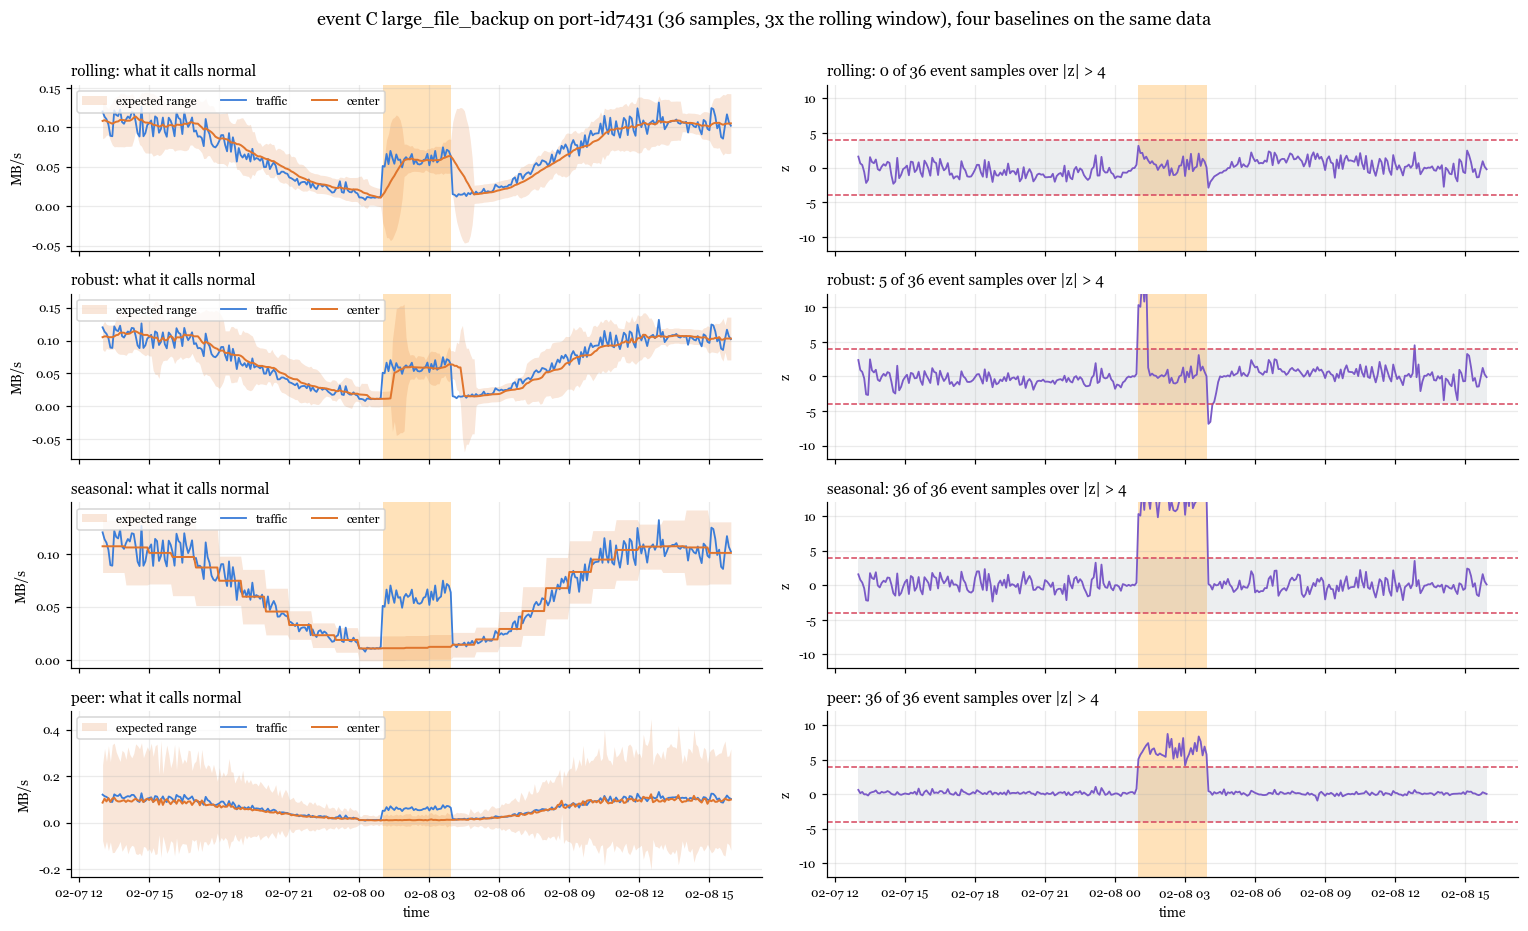

In [4]:
# One event, four references. Left column: what each baseline calls normal, drawn as a band.
# Right column: the score that band produces, on a shared axis so the four are comparable.
# Reading the band alone is misleading, because a band that looks wide on a MB/s axis can
# still be narrow relative to the local scale, and it is the score that gets thresholded.
ev = events[events.event_id == "C"].iloc[0]
pad = pd.Timedelta("12h")
w = tel[(tel["port_id"] == ev.port_id)
        & tel["timestamp"].between(ev.start - pad, ev.end + pad)].reset_index(drop=True)
inside = event_window(w, ev)

fig, axes = plt.subplots(len(BASELINES), 2, figsize=(14, 2.1 * len(BASELINES)), sharex=True)
for (left, right), b in zip(axes, BASELINES):
    left.fill_between(w["timestamp"], (w[f"{b}_center"] - 3 * w[f"{b}_scale"]) / 1e6,
                      (w[f"{b}_center"] + 3 * w[f"{b}_scale"]) / 1e6,
                      color=C["baseline"], alpha=0.18, lw=0, label="expected range")
    left.plot(w["timestamp"], w[COL] / 1e6, color=C["signal"], lw=1.2, label="traffic")
    left.plot(w["timestamp"], w[f"{b}_center"] / 1e6, color=C["baseline"], lw=1.3, label="center")
    left.set(ylabel="MB/s", title=f"{b}: what it calls normal")
    left.legend(loc="upper left", ncol=3)

    z = w[f"z_{b}"]
    right.plot(w["timestamp"], z, color=C["score"], lw=1.2)
    right.fill_between(w["timestamp"], -THRESHOLD, THRESHOLD, color=C["muted"], alpha=0.18, lw=0)
    right.axhline(THRESHOLD, color=C["alert"], ls="--", lw=1.0)
    right.axhline(-THRESHOLD, color=C["alert"], ls="--", lw=1.0)
    right.set(ylabel="z", ylim=(-12, 12),
              title=f"{b}: {int((z.abs() > THRESHOLD)[inside].sum())} of {int(inside.sum())} "
                    f"event samples over |z| > {THRESHOLD:g}")
    for ax in (left, right):
        shade(ax, w["timestamp"], inside)
for ax in axes[-1]:
    ax.set_xlabel("time")
fig.suptitle(f"event C large_file_backup on {ev.port_id} ({int(ev.n)} samples, "
             f"{int(ev.n) / WINDOW:.0f}x the rolling window), four baselines on the same data",
             y=1.002)
fig.tight_layout(); plt.show()

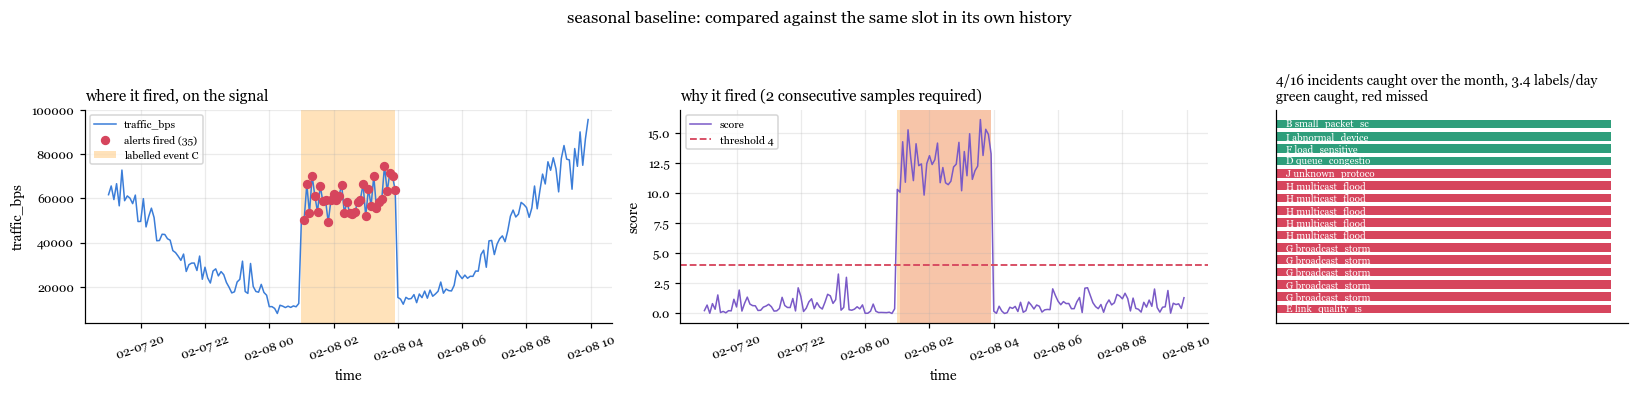

seasonal baseline (traffic_bps) threshold         4 | recall  4/16 |    3.40 labels/day | delay   5.0 min | event E ✗


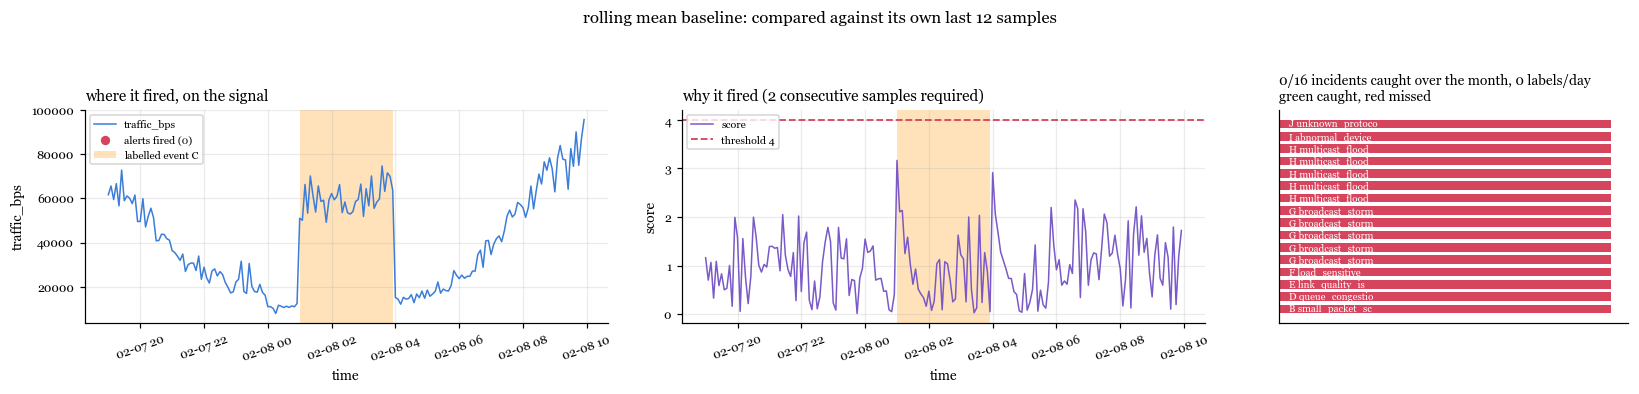

rolling baseline (traffic_bps) threshold         4 | recall  0/16 |    0.00 labels/day | delay   nan min | event E ✗


In [5]:
# The one that reads best on paper, drawn on the event that separates the four. Swap the
# name to see any of the others fire on the same window.
plot_detection(DETS["seasonal"], tel, event_id="C", col=COL,
               title="seasonal baseline: compared against the same slot in its own history")
plot_detection(DETS["rolling"], tel, event_id="C", col=COL,
               title="rolling mean baseline: compared against its own last 12 samples")

### 小結

同一段資料、同一個門檻，四個判決差很遠。左欄看得到機制。

event C 進來之後 rolling 的 center 隨之上移、band 同時變寬，分子縮小分母變大，兩個方向一起把分數壓下去，所以它一筆都沒抓到。robust 的 center 移動得慢一些，但這個 event 有 36 筆而 window 只有 12 筆，污染早就過半，所以它也只多抓幾筆。seasonal 的參考來自歷史上同一個時段，結構上不可能被眼前這段 event 污染，這是它全抓的唯一原因，與方法本身的優劣無關。

兩張 plot_detection 的 左圖把這件事講得更直白：seasonal 的紅點鋪滿整個橘色區塊，rolling 的 左圖上一顆紅點都沒有。

### 探索練習：seasonal 的 bucket 怎麼切

**任務**：把 `seasonal()` 的 `by_weekend` 關掉，等於假設週末與平日的節律一樣。

```python
sc, ss = seasonal(g, COL, by_weekend=False)
```

觀察：

- 哪一個 port 最先出問題？
- event C 的命中數從 36 掉到多少？

**討論**：bucket 切得越細估計越貼身，每一格的樣本數也越少。改成 day-of-week 乘以小時，bucket 變七倍細，樣本數掉到七分之一。`peer()` 那邊也有一個對應的開關，把 leave-one-out 拿掉，port 自己會進到自己的參考裡，偏差往零壓。

## 第 3 步：四種 baseline 的命中與代價

一張圖看兩件事：抓到幾個 event window，以及在正常樣本上越線的比例。沒有哪一種是全面最好，每一種都在某個可證明的案例上失敗。

,name,recall,of,labels_per_day,median_delay_min,caught_E
0,rolling baseline (traffic_bps),0,16,0.00,NaN,False
1,robust baseline (traffic_bps),3,16,1.77,5.0,False
2,seasonal baseline (traffic_bps),4,16,3.40,5.0,False
3,peer baseline (traffic_bps),2,16,2.03,5.0,False


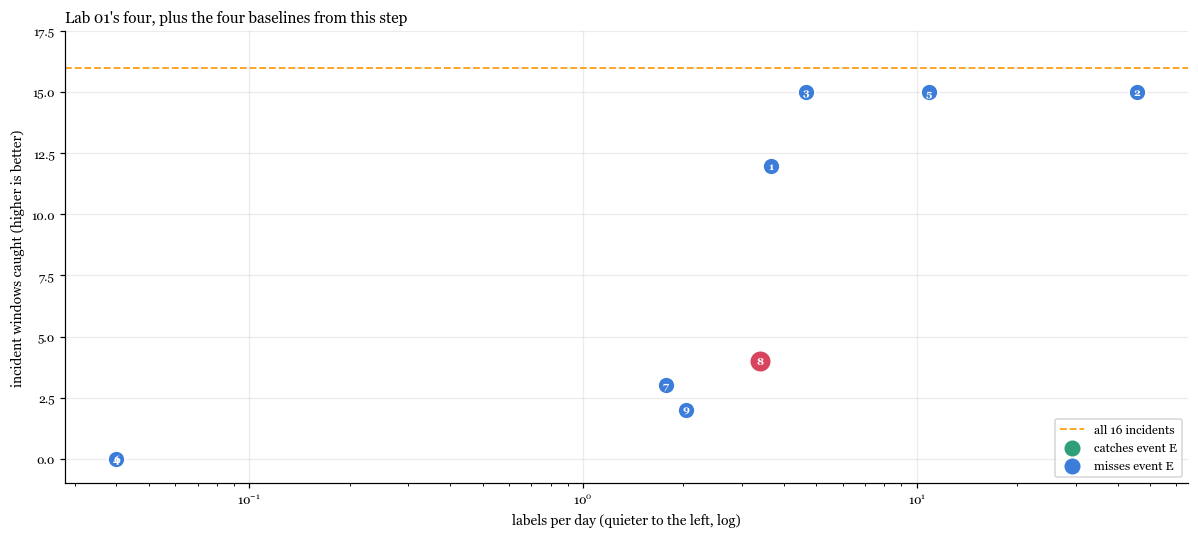

,method,caught,labels/day,delay (min),event E
1,"two columns, unfiltered",12,3.67,5.0,False
2,"two columns, median filter k=9",15,45.71,5.0,False
3,"two columns, 30min buckets",15,4.67,25.0,False
4,"rolling mean z, 7 cols",0,0.00,NaN,False
5,"robust z, 7 cols",15,10.87,5.0,False
6,rolling baseline (traffic_bps),0,0.00,NaN,False
7,robust baseline (traffic_bps),3,1.77,5.0,False
8,seasonal baseline (traffic_bps),4,3.40,5.0,False
9,peer baseline (traffic_bps),2,2.03,5.0,False


,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
1,"two columns, unfiltered",4.0,12,16,3.67,5.0,False
2,"two columns, median filter k=9",4.0,15,16,45.71,5.0,False
3,"two columns, 30min buckets",4.0,15,16,4.67,25.0,False
4,"rolling mean z, 7 cols",4.0,0,16,0.00,NaN,False
5,"robust z, 7 cols",4.0,15,16,10.87,5.0,False
6,rolling baseline (traffic_bps),4.0,0,16,0.00,NaN,False
7,robust baseline (traffic_bps),4.0,3,16,1.77,5.0,False
8,seasonal baseline (traffic_bps),4.0,4,16,3.40,5.0,False
9,peer baseline (traffic_bps),4.0,2,16,2.03,5.0,False


In [6]:
# Nothing new is computed here. The four detectors already exist, so this step only puts
# their scorecards side by side and adds them to the running ledger picture.
compare = pd.DataFrame([DETS[b].card for b in BASELINES])
display(compare[["name", "recall", "of", "labels_per_day", "median_delay_min", "caught_E"]])

plot_ledger(highlight=f"seasonal baseline ({COL})",
            title="Lab 01's four, plus the four baselines from this step")

### 小結

四個 baseline 的成績單擺在一起，命中是 0、3、4、2，每日告警量是 0.00、1.77、3.40、2.03。

rolling mean 的兩個數字都是零，整個月沒有產生任何一個 label。原因跟上一步同一個：event 進到自己的參考 window 裡，把 baseline 一起帶走。一個從不觸發的偵測器在「每日告警量」這一欄看起來是最好的，這正是為什麼那一欄不能單獨看。

seasonal 抓得最多，也最吵；peer 抓得比 seasonal 少，但也比較安靜。兩者的取捨在於可接受的每日告警量，這張 ledger 上它們一個在另一個的右上方，沒有一個支配另一個。peer 真正的價值也不在這張圖上，而在它不需要任何歷史就能對一個全新的 port 計分。

沒有一根長條接近 16。單一 feature 加單一 baseline 的組合到這裡就到頂了，後面每一步都在補這個缺口的某一面。

### 探索練習：調整 threshold

**任務**：把 `THRESHOLD` 從 4 改成 3，重新執行這一格。

```python
THRESHOLD = 3.0
```

觀察：

- 表格裡四個 baseline 各多命中幾個 window？
- 每日筆數各漲幾倍？ledger 上那四個點往哪個方向移動？

**討論**：沒有任何一根長條碰到右邊那條線，這不是調參不夠努力，是每一種比較對象各有一類 event 結構性地測不到。實務的答案是同時跑多種再取最大值；取最大值以外還有投票（至少兩種都越線）與加權，前者更安靜，後者需要一組沒有根據的權重。

## 第 4 步：robust 統計的 breakdown point

median 與 MAD 的關鍵性質叫 **breakdown point**：污染樣本超過一半之前，估計值仍然被乾淨資料的值域框住，不會被污染值本身拉走。這不等於不動，下面會量出它動了多少。mean 沒有這個保護，第一個 outlier 就開始把它往外拉，而且沒有上限。

直接量給你看：拿一段乾淨資料，逐步把其中一定比例的樣本換成大值，看兩組估計量各自怎麼反應。

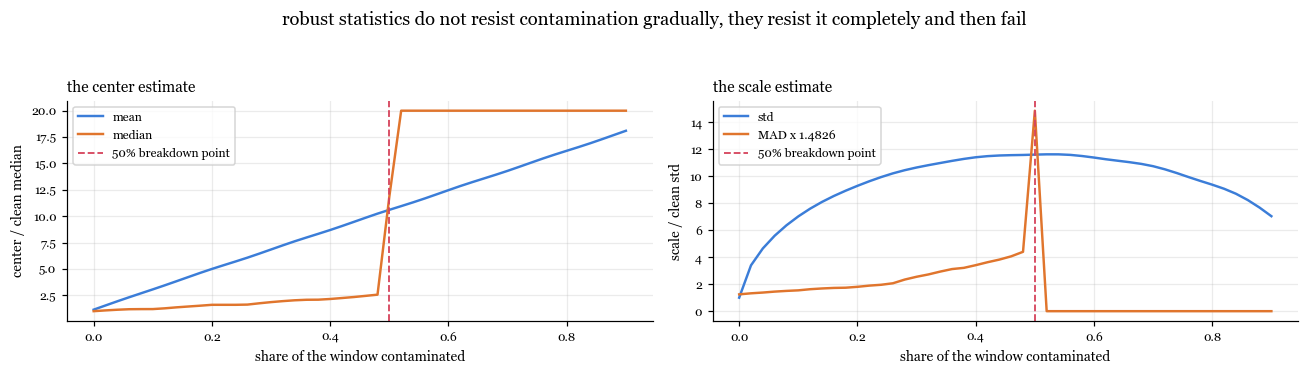

In [7]:
# Take one quiet stretch, replace an increasing share of it with a large value, and watch
# the two estimator pairs respond. This is the breakdown point, measured rather than quoted.
clean = tel[(tel["port_id"] == ports[0]) & ~tel["is_incident"]][COL].to_numpy()[:2000]
spike = np.median(clean) * 20
fractions = np.linspace(0, 0.9, 46)

rows = []
for frac in fractions:
    x = clean.copy()
    k = int(len(x) * frac)
    x[:k] = spike                                    # contaminate the first k samples
    rows.append({"contamination": frac,
                 "mean": x.mean() / np.median(clean),
                 "median": np.median(x) / np.median(clean),
                 "std": x.std() / np.std(clean),
                 "mad": np.median(np.abs(x - np.median(x))) * MAD_TO_SIGMA / np.std(clean)})
bd = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharex=True)
axes[0].plot(bd["contamination"], bd["mean"], color=C["signal"], lw=1.6, label="mean")
axes[0].plot(bd["contamination"], bd["median"], color=C["baseline"], lw=1.6, label="median")
axes[0].set(xlabel="share of the window contaminated", ylabel="center / clean median",
            title="the center estimate")
axes[1].plot(bd["contamination"], bd["std"], color=C["signal"], lw=1.6, label="std")
axes[1].plot(bd["contamination"], bd["mad"], color=C["baseline"], lw=1.6, label="MAD x 1.4826")
axes[1].set(xlabel="share of the window contaminated", ylabel="scale / clean std",
            title="the scale estimate")
for ax in axes:
    ax.axvline(0.5, color=C["alert"], ls="--", lw=1.2, label="50% breakdown point")
    ax.legend()
fig.suptitle("robust statistics do not resist contamination gradually, they resist it "
             "completely and then fail", y=1.05)
fig.tight_layout(); plt.show()

### 小結

這張圖修正一個常見的誤解。**median 並不是在 50% 之前完全不動。** 污染到 40% 的時候，median 已經上升 116%，因為單邊的污染把中位數的位置推到乾淨資料自己的高分位上。

50% 這個 breakdown point 保證的是另一件事：在那之前，估計值仍然被乾淨資料的值域框住，不會被污染值本身拉走；過了那條線，median 直接跳到污染值。mean 沒有這個保護，同樣 40% 污染下它已經是乾淨值的 8.7 倍，而且會隨污染幅度無上限地增加。

所以 robust 保證的是有界，而不是不動。

### 探索練習：污染的幅度與位置

**任務**：把 `spike` 從 median 的 20 倍改成 2 倍。

```python
spike = np.median(clean) * 2
```

觀察：

- breakdown point 的位置變了嗎？
- 崩潰之後兩條線各跳到多高？

**討論**：幅度影響的是崩潰之後跳多高，不是崩潰在哪裡發生。median 與 MAD 的 breakdown point 是 50%，IQR 是 25%，trimmed mean 由裁掉的比例決定，要更高的 breakdown point 就要付更多 statistical efficiency。

## 第 5 步：threshold 4.0 的實測越線率

常態假設下 $|z| > 4$ 是個很小的機率，實測的越線比例遠高於它。三個效應疊加：流量分佈重尾、MAD 在安靜時段塌到下限把 score 推高、樣本之間高度 autocorrelated 使一次 event 貢獻連續好幾筆越線。

只假設變異數有限的 Chebyshev bound $P(|X - \mu| \ge k\sigma) \le 1/k^2$ 涵蓋得住實測；常態表差好幾個數量級，等於假設了資料上不存在的規律。

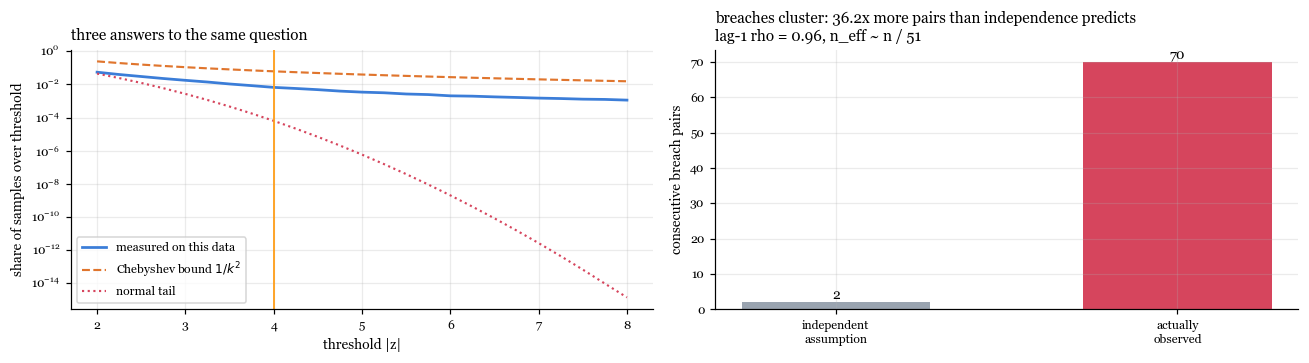

13 features x 5 ports x time = 561,600 decisions this month
Bonferroni alpha/m = 8.9e-08  ->  |z| > 5.35


In [8]:
from scipy.stats import norm

score = tel["z_robust"].abs()
t_axis = np.linspace(2, 8, 25)
observed = np.array([(score > t).mean() for t in t_axis])
gauss = 2 * (1 - norm.cdf(t_axis))                   # normal tail, both sides
cheby = 1 / t_axis ** 2                              # only assumes a finite variance

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].plot(t_axis, observed, color=C["signal"], lw=1.8, label="measured on this data")
axes[0].plot(t_axis, cheby, color=C["baseline"], lw=1.4, ls="--", label="Chebyshev bound $1/k^2$")
axes[0].plot(t_axis, gauss, color=C["alert"], lw=1.4, ls=":", label="normal tail")
axes[0].axvline(THRESHOLD, color=C["truth"], lw=1.2)
axes[0].set_yscale("log")
axes[0].set(xlabel="threshold |z|", ylabel="share of samples over threshold",
            title="three answers to the same question")
axes[0].legend()

# Autocorrelation is why breaches arrive in clusters: the effective sample size is a
# fraction of the nominal one, so consecutive breaches are far commoner than independence predicts.
s1 = tel[tel["port_id"] == ports[0]][COL].reset_index(drop=True)
rho = float(s1.autocorr(lag=1))
n_eff_ratio = (1 - rho) / (1 + rho)
p = float((score > THRESHOLD).mean())
expected_pairs = p ** 2 * len(tel)
actual_pairs = int((( score > THRESHOLD) & (score.shift(1) > THRESHOLD)).sum())

axes[1].bar(["independent\nassumption", "actually\nobserved"], [expected_pairs, actual_pairs],
            color=[C["muted"], C["alert"]], width=0.55)
for n, v in enumerate([expected_pairs, actual_pairs]):
    axes[1].text(n, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set(ylabel="consecutive breach pairs",
            title=f"breaches cluster: {actual_pairs / expected_pairs:.1f}x more pairs than "
                  f"independence predicts\nlag-1 rho = {rho:.2f}, n_eff ~ n / {1 / n_eff_ratio:.0f}")
fig.tight_layout(); plt.show()

m = len(FEATURES) * len(ports) * len(tel) // len(ports)
print(f"{len(FEATURES)} features x {len(ports)} ports x time = {m:,} decisions this month")
print(f"Bonferroni alpha/m = {0.05 / m:.1e}  ->  |z| > {norm.ppf(1 - 0.05 / m / 2):.2f}")

### 小結

實測越線比例 0.67%，常態表算出來是 0.0063%，**差 106 倍**。只假設變異數有限的 Chebyshev 上界給 6.25%，涵蓋得住實測。

第二張圖是原因之一。假設每筆越線互相獨立，連續兩筆越線的期望次數是 2 次，實際是 70 次，**差 35 倍**。lag-1 自相關 0.962，越線本來就會成群出現。

實務結論：不要用常態表反推門檻。把誤報與漏抓合成 alerts per day 這一個量，它自動吸收了自相關與多重檢定，而且值班的人聽得懂。

### 探索練習：換一個 score 看尾端

**任務**：把 左圖的 `score` 換成 `z_seasonal`，再換成 `z_peer`。

```python
score = tel["z_seasonal"].abs()
```

觀察：

- 實測曲線離常態線更近還是更遠？
- 越線比例差幾倍？

**討論**：Bonferroni 控的是 family-wise error rate，Benjamini-Hochberg 控的是 false discovery rate，在監控場景 FDR 比較合用，因為在意的是「發出去的 alert 裡有幾成是假的」。實務上把 false alarm 與漏抓合成 alerts per day 這一個量，自動吸收了 autocorrelation 與 multiple testing，而且值班的人聽得懂。

## 第 6 步：CUSUM

上面每一種 baseline 都在同一種情形下失效：半個 sigma 的偏移持續不斷，逐一樣本看沒有一筆特別不尋常。z-score 只看當前 window，window 之前的偏離不進入計算。

CUSUM 問的是**累積**的偏差夠不夠大，不是這單一讀數夠不夠遠。兩個參數各對應一個維運問題：`k` 是 deadband，多小的偏差可以完全忽略；`h` 是 decision limit，需要多少累積證據才行動。

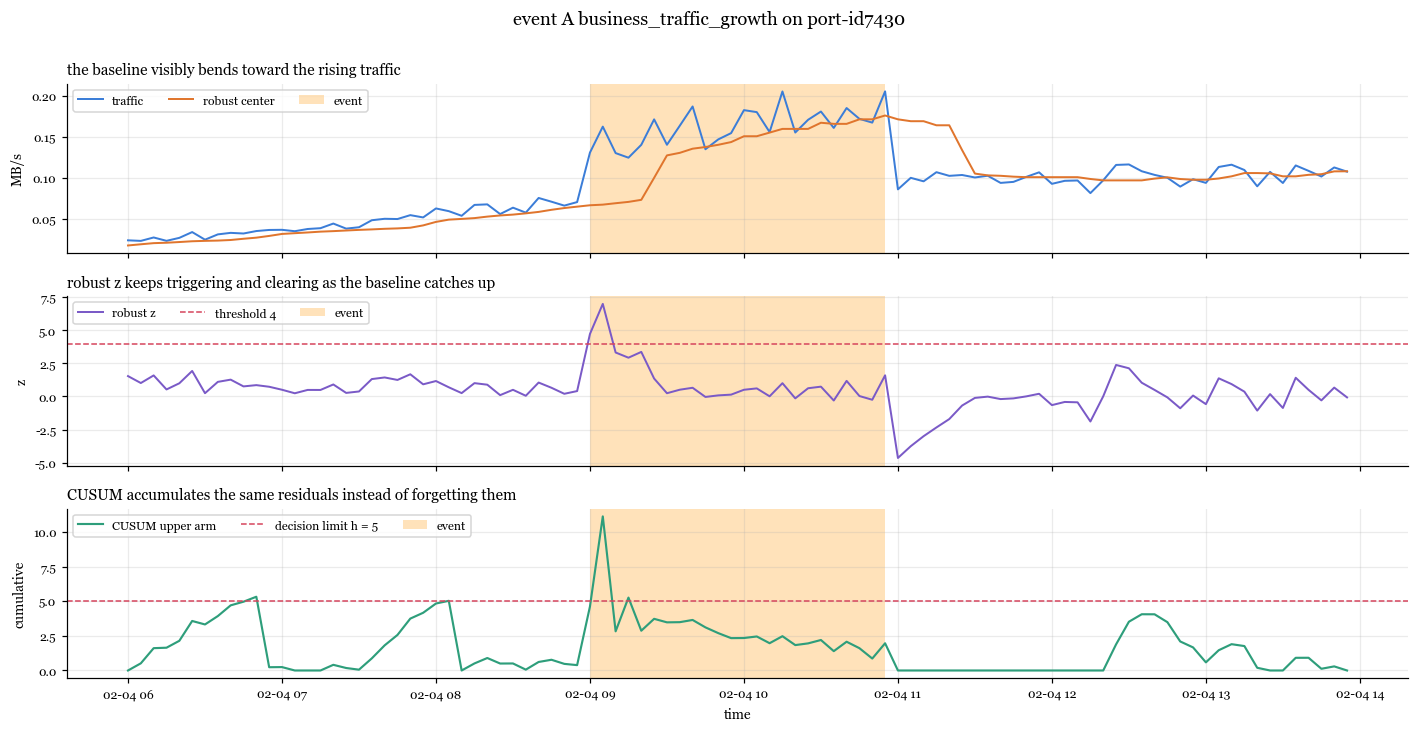

In [9]:
def cusum(z, k=0.5, h=5.0):
    """Two-sided cumulative sum of a deadbanded standardised residual.

    Each step adds the residual minus the deadband k and floors the running total at zero,
    so pure noise cannot creep upward, while a small persistent offset accumulates. The
    recursion carries state across samples, which is exactly what a z-score refuses to do.
    """
    z = np.nan_to_num(np.asarray(z, float))
    pos = neg = 0.0
    up, down, sig = np.zeros(len(z)), np.zeros(len(z)), np.zeros(len(z), bool)
    for i in range(1, len(z)):
        pos = max(0.0, pos + z[i] - k)               # upward arm
        neg = max(0.0, neg - z[i] - k)               # downward arm, symmetric
        up[i], down[i] = pos, neg
        if pos > h or neg > h:
            sig[i] = True
            pos = neg = 0.0                          # reset after signalling
    return pd.DataFrame({"cusum_up": up, "cusum_down": down, "cusum_signal": sig})


# Event A is a slow ramp: no single sample is extreme, which is the case CUSUM exists for.
ea = events[events.event_id == "A"].iloc[0]
pad = pd.Timedelta("3h")
w = tel[(tel["port_id"] == ea.port_id)
        & tel["timestamp"].between(ea.start - pad, ea.end + pad)].reset_index(drop=True)
w = pd.concat([w, cusum(w["z_robust"], k=0.5, h=5.0)], axis=1)

fig, axes = plt.subplots(3, 1, figsize=(13, 6.6), sharex=True)
axes[0].plot(w["timestamp"], w[COL] / 1e6, color=C["signal"], lw=1.3, label="traffic")
axes[0].plot(w["timestamp"], w["robust_center"] / 1e6, color=C["baseline"], lw=1.3,
             label="robust center")
axes[0].set(ylabel="MB/s", title="the baseline visibly bends toward the rising traffic")

axes[1].plot(w["timestamp"], w["z_robust"], color=C["score"], lw=1.3, label="robust z")
axes[1].axhline(THRESHOLD, color=C["alert"], ls="--", lw=1.0, label=f"threshold {THRESHOLD:g}")
axes[1].set(ylabel="z", title="robust z keeps triggering and clearing as the baseline catches up")

axes[2].plot(w["timestamp"], w["cusum_up"], color=C["peer"], lw=1.4, label="CUSUM upper arm")
axes[2].axhline(5.0, color=C["alert"], ls="--", lw=1.0, label="decision limit h = 5")
axes[2].set(ylabel="cumulative", xlabel="time",
            title="CUSUM accumulates the same residuals instead of forgetting them")

for ax in axes:
    shade(ax, w["timestamp"], event_window(w, ea))
    ax.legend(loc="upper left", ncol=3)
fig.suptitle(f"event A business_traffic_growth on {ea.port_id}", y=1.002)
fig.tight_layout(); plt.show()

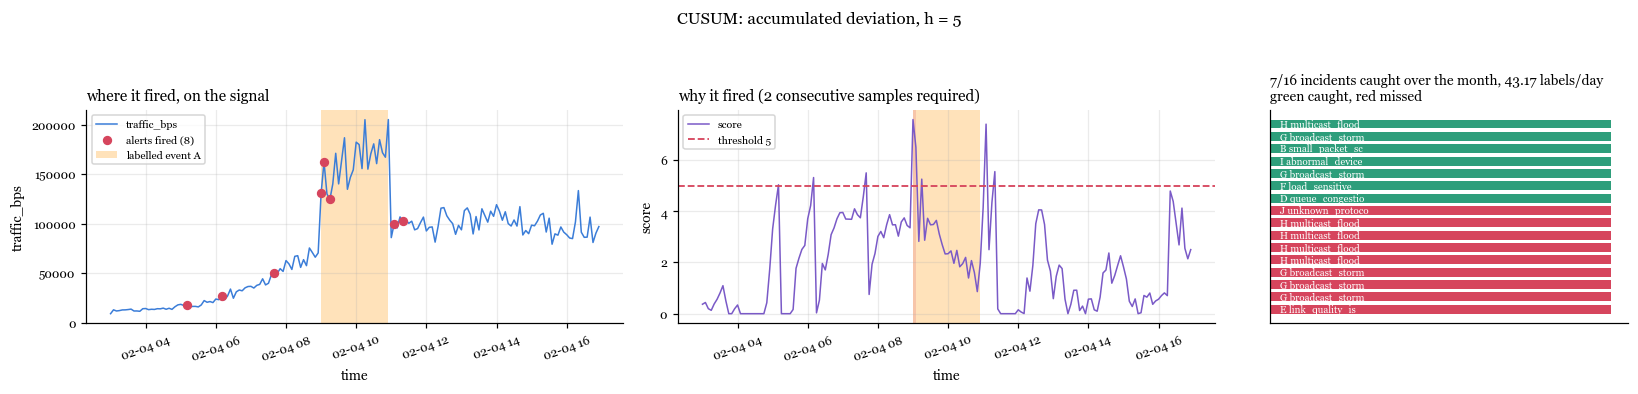

CUSUM (k=0.5, h=5)         threshold         5 | recall  7/16 |   43.17 labels/day | delay   0.0 min | event E ✗


In [10]:
# cusum() is defined in the cell above; this cell only wraps it into a score that
# rollout can consume, one port at a time.
def cusum_score(frame, col="z_robust", k=0.5, h=5.0):
    """The larger of the two arms, per port, with the reset that the algorithm requires.

    h has to be passed in rather than left to the rollout: it is not a display threshold,
    it is part of the recursion, because crossing it empties the accumulator. Removing the
    reset makes the arms grow without bound and the detector fires forever after the first
    real event.
    """
    out = pd.Series(0.0, index=frame.index)
    for pid, g in frame.groupby("port_id", observed=True):
        g = g.sort_values("timestamp")
        c = cusum(g[col], k=k, h=h)
        out.loc[g.index] = np.maximum(c["cusum_up"], c["cusum_down"]).to_numpy()
    return out


# n_consecutive=1 here, and only here. The confirmation layer exists to give a memoryless
# score some persistence; CUSUM already accumulates persistence by construction, and the
# reset means its arm is over the limit for exactly one sample. Asking for two in a row
# would charge this detector twice for the same property and silence it completely.
H = 5.0
det_cusum = rollout("CUSUM (k=0.5, h=5)", cusum_score(tel, h=H), tel, threshold=H,
                    n_consecutive=1)
plot_detection(det_cusum, tel, event_id="A", col=COL, title="CUSUM: accumulated deviation, h = 5")

### 小結

先看單一 event。在 event A 的 24 筆裡，robust z 越過 4 的有 2 筆，CUSUM 觸發也是 2 次，**這個 event 上 CUSUM 沒有多抓到任何東西**。event A 的爬升幅度夠大，單筆就能越線，它本來就不是 CUSUM 的目標案例。

全月的成績單是另一回事：7/16，每天 43.17 筆。比前面任何一個 baseline 都抓得多，也吵得多。plot_detection 右圖那一欄綠色明顯變長，代價寫在旁邊。

差別在中圖的分數形狀。z 在越線之後立刻回落，因為 baseline 已經移到新水位；CUSUM 的累積量在整段爬升中持續為正，累積量表示偏離仍在持續，而不是這一瞬間特別極端。延遲中位數是 0 分鐘，因為累積量在 event 開始前就已經在爬。

這一步的 rollout 用了 `n_consecutive=1`，是整本唯一的例外。確認層是為了給不跨樣本累積的分數補上持續性，而 CUSUM 本身就是累積式的，而且越過 h 之後會歸零，所以它的分數本來就只會超標一筆。再要求連續兩筆等於把同一個性質收兩次錢，結果是它一個都抓不到。

### 探索練習：CUSUM 的兩個旋鈕

**任務**：把 `k` 調到 0.1，再把 `h` 調到 10，各執行一次。

```python
w = pd.concat([w, cusum(w["z_robust"], k=0.1, h=5.0)], axis=1)
```

觀察：

- `k` 變小之後，安靜時段的累積量是不是也開始往上爬？
- `h` 變大之後，訊號晚了幾筆？

**討論**：這兩個旋鈕不能同時改善速度與 false alarm。CUSUM 吃的 residual 現在來自 robust baseline，換成 rolling mean，baseline 被污染時 CUSUM 跟著失效。所有 port 共用同一組 `k` 與 `h`，累積速度不同的 port 其實該有不同的 deadband。

## 第 7 步：EWMA

exponentially weighted moving average 對舊資料的權重按幾何級數衰減。記憶長度約 $(2-\lambda)/\lambda$ 筆，$\lambda = 0.2$ 大約是 9 筆。control limit 是 $\pm L \sigma \sqrt{\lambda / (2-\lambda)}$。

比 rolling window 多了「舊資料不是說丟就丟」的平滑，比 CUSUM 少了 deadband 這個要調的參數。代價是慢，兩次都慢：到頂比 z 晚，退回底線也比 z 晚。

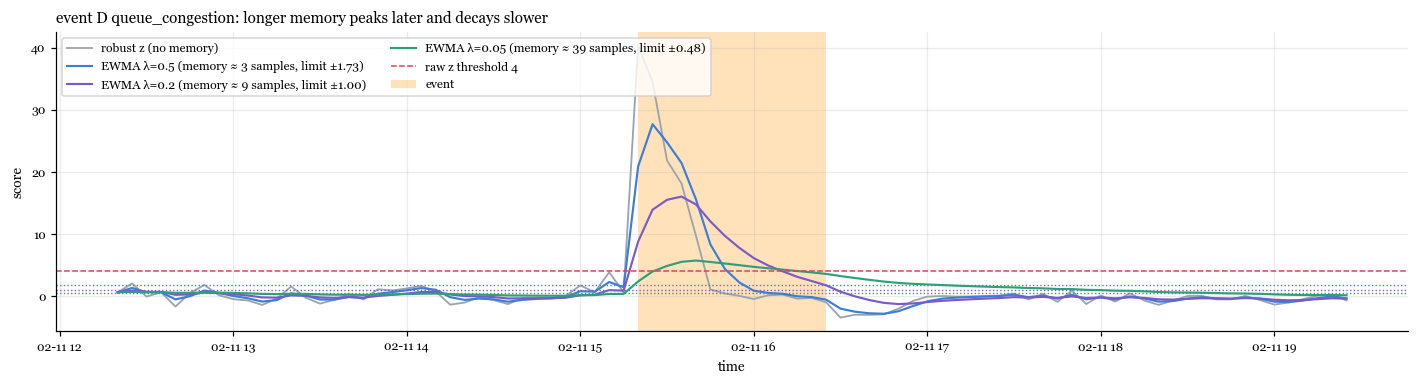

In [11]:
# Event D is a short sharp spike, the opposite of event A, so it shows EWMA's cost plainly.
ed = events[events.event_id == "D"].iloc[0]
pad = pd.Timedelta("3h")
w = tel[(tel["port_id"] == ed.port_id)
        & tel["timestamp"].between(ed.start - pad, ed.end + pad)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(w["timestamp"], w["z_robust"], color=C["muted"], lw=1.2, label="robust z (no memory)")
for lam, colour in [(0.5, C["signal"]), (0.2, C["score"]), (0.05, C["peer"])]:
    e = w["z_robust"].ewm(alpha=lam, adjust=False).mean()
    limit = 3.0 * np.sqrt(lam / (2 - lam))           # L = 3 control limit for this lambda
    ax.plot(w["timestamp"], e, color=colour, lw=1.4,
            label=f"EWMA λ={lam} (memory ≈ {(2 - lam) / lam:.0f} samples, limit ±{limit:.2f})")
    ax.axhline(limit, color=colour, ls=":", lw=0.9)
ax.axhline(THRESHOLD, color=C["alert"], ls="--", lw=1.0, label=f"raw z threshold {THRESHOLD:g}")
shade(ax, w["timestamp"], event_window(w, ed))
ax.set(ylabel="score", xlabel="time",
       title="event D queue_congestion: longer memory peaks later and decays slower")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout(); plt.show()

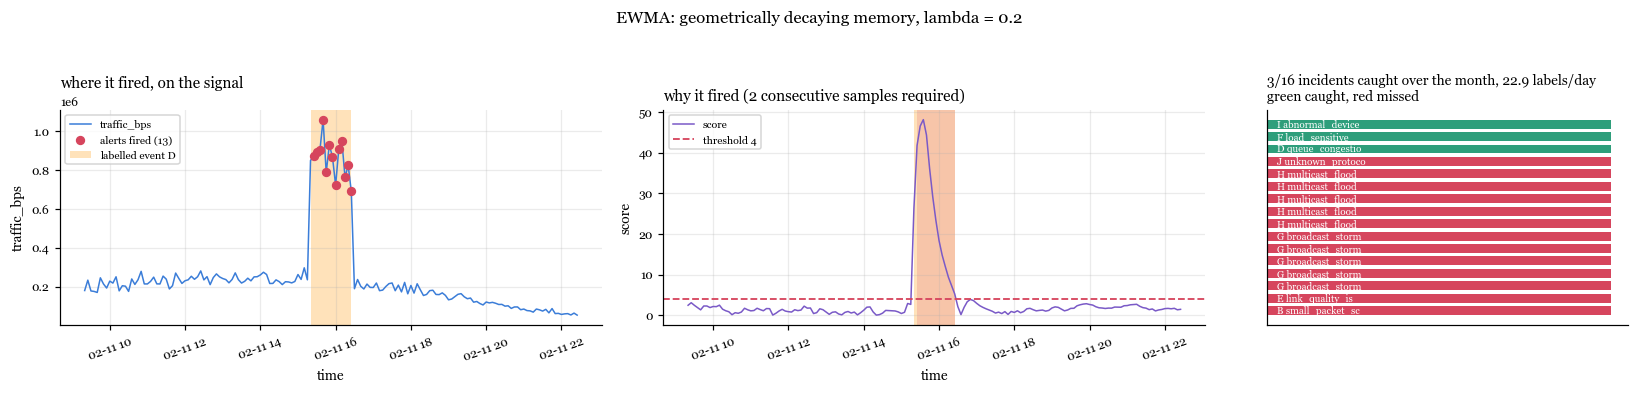

EWMA (λ=0.2)               threshold         4 | recall  3/16 |   22.90 labels/day | delay   5.0 min | event E ✗


In [12]:
def ewma_score(frame, col="z_robust", lam=0.2):
    """Exponentially weighted mean of the residual, per port, expressed on its own limit.

    Dividing by the control limit L*sqrt(lam/(2-lam)) puts every lambda on the same axis,
    so one threshold means the same thing whatever memory length you pick.
    """
    limit = np.sqrt(lam / (2 - lam))
    out = pd.Series(0.0, index=frame.index)
    for pid, g in frame.groupby("port_id", observed=True):
        g = g.sort_values("timestamp")
        out.loc[g.index] = (g[col].ewm(alpha=lam, adjust=False).mean() / limit).abs().to_numpy()
    return out


det_ewma = rollout("EWMA (λ=0.2)", ewma_score(tel), tel, threshold=THRESHOLD)
plot_detection(det_ewma, tel, event_id="D", col=COL, title="EWMA: geometrically decaying memory, lambda = 0.2")

### 小結

三條 EWMA 的峰值時間依序落後，λ 越小落後越多，退回控制界線也越慢。這是記憶換靈敏度的代價，兩端都要付。

control limit 隨 λ 一起縮：$\pm L \sigma \sqrt{\lambda/(2-\lambda)}$ 在 λ=0.2 時只有原始 z 門檻的一小部分，所以不能拿 EWMA 的值直接跟 4 比。`ewma_score()` 因此先除以那個界線，把不同 λ 拉到同一個軸上，門檻才有辦法沿用 4。

全月 3/16、每天 22.9 筆，每日筆數約為 CUSUM 的一半，也少抓四個。兩者都讓分數跨樣本累積，累積方式不同，落點也不同。

event D 是急漲急落，這是 EWMA 最不擅長的形狀，選它正是為了讓代價可見。

### 探索練習：記憶長度與控制界線

**任務**：加一條 `lam = 0.02` 的線，並把 `L` 從 3.0 改成 2.5。

```python
for lam, colour in [(0.5, C["signal"]), (0.2, C["score"]), (0.02, C["peer"])]:
```

觀察：

- λ 越小，峰值晚多久出現？
- L 變小之後，安靜時段有沒有開始越線？

**討論**：λ 與 L 要一起調，單獨動一個等於同時改了靈敏度與 false alarm 率。CUSUM、EWMA、rolling window 三者的共同弱點是參考區間裡混進了 event 本身，換偵測器解決不了輸入端的問題。

## 第 8 步：change-point detection

到目前為止所有方法都在問「這個讀數離參考點多遠」。另一個同樣真實的問題是：底層的**水平**是不是已經永久移到另一個狀態，而不管任何單一樣本看起來極不極端。

dual moving average：短的追蹤現在，長的追蹤現在之前的近期，兩者的相對差距就是訊號。threshold 取序列自己的 p90，不從別處借。

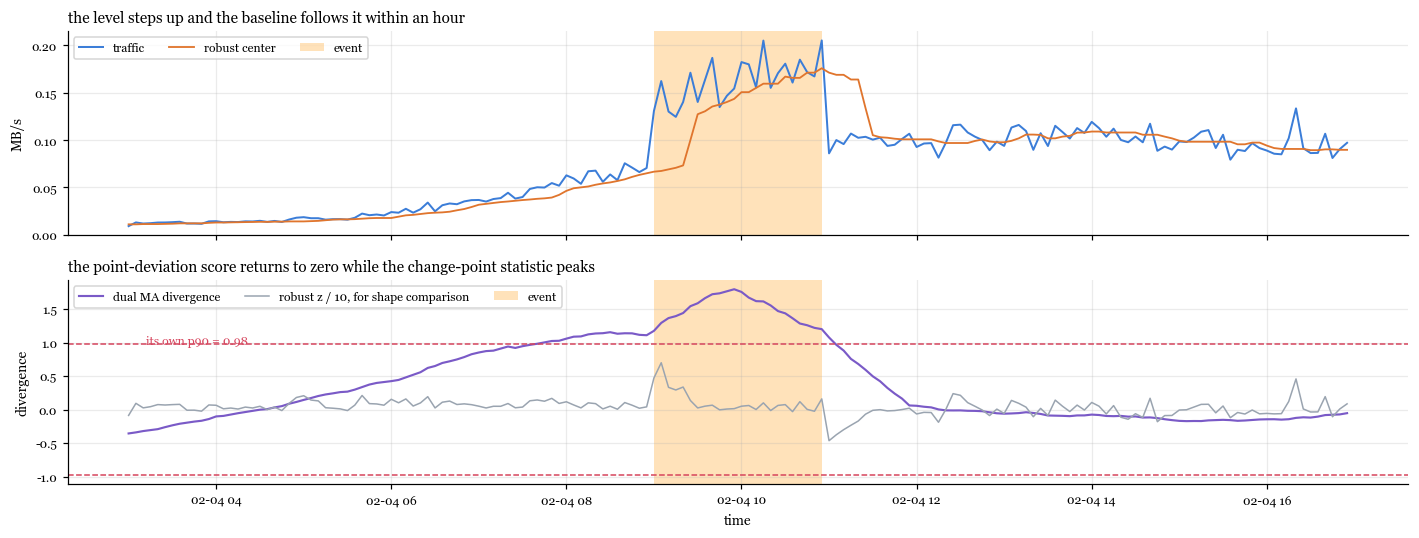

In [13]:
def dual_ma(v, short, long):
    """Relative gap between a fast and a slow moving average. A stable series keeps them together."""
    fast = v.rolling(short, min_periods=short // 2).mean()
    slow = v.rolling(long, min_periods=long // 2).mean()
    return (fast - slow) / (slow.abs() + 1e-9)


cp = tel[tel["port_id"] == ea.port_id].sort_values("timestamp").reset_index(drop=True)
cp["dual_ma"] = dual_ma(cp[COL], WINDOW, 6 * WINDOW)
p90 = float(cp["dual_ma"].abs().quantile(0.90))

pad = pd.Timedelta("6h")
w = cp[cp["timestamp"].between(ea.start - pad, ea.end + pad)]

fig, axes = plt.subplots(2, 1, figsize=(13, 5.0), sharex=True)
axes[0].plot(w["timestamp"], w[COL] / 1e6, color=C["signal"], lw=1.3, label="traffic")
axes[0].plot(w["timestamp"], w["robust_center"] / 1e6, color=C["baseline"], lw=1.2,
             label="robust center")
axes[0].set(ylabel="MB/s", title="the level steps up and the baseline follows it within an hour")
axes[1].plot(w["timestamp"], w["dual_ma"], color=C["score"], lw=1.4, label="dual MA divergence")
axes[1].plot(w["timestamp"], w["z_robust"] / 10, color=C["muted"], lw=1.0,
             label="robust z / 10, for shape comparison")
for lvl in (p90, -p90):
    axes[1].axhline(lvl, color=C["alert"], ls="--", lw=1.0)
axes[1].text(w["timestamp"].iloc[2], p90, f" its own p90 = {p90:.2f}", fontsize=8, color=C["alert"])
axes[1].set(ylabel="divergence", xlabel="time",
            title="the point-deviation score returns to zero while the change-point statistic peaks")
for ax in axes:
    shade(ax, w["timestamp"], event_window(w, ea))
    ax.legend(loc="upper left", ncol=3)
fig.tight_layout(); plt.show()

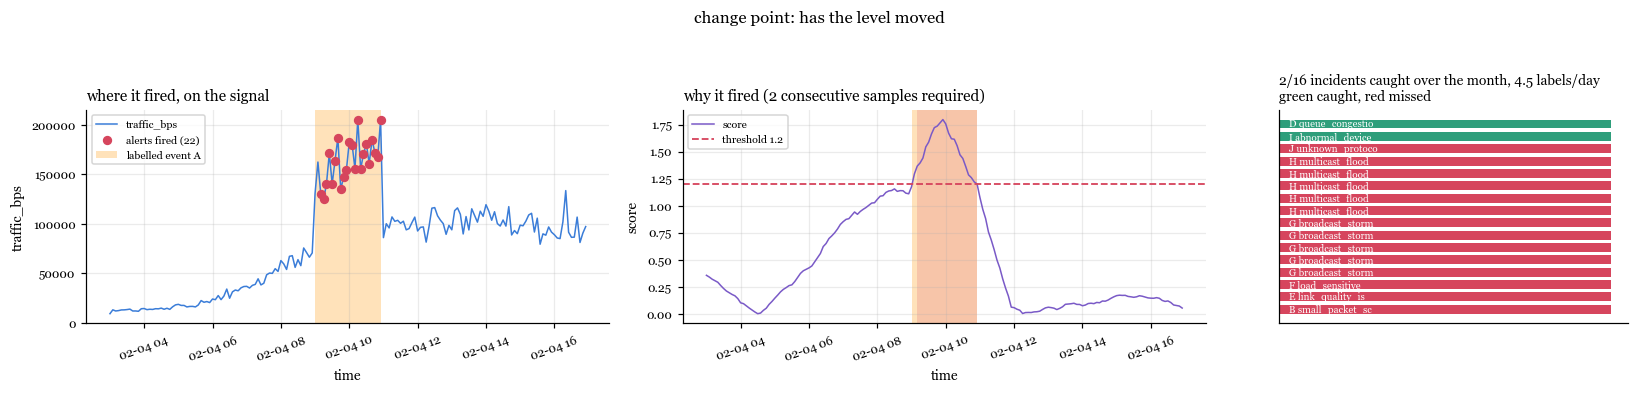

change point (dual MA)     threshold     1.201 | recall  2/16 |    4.50 labels/day | delay  22.5 min | event E ✗


In [14]:
# dual_ma() is defined in the cell above.
def changepoint_score(frame, col=None, short=None, long_mult=6):
    """How far apart the fast and slow averages have drifted, per port, as an absolute score."""
    col = col or COL
    out = pd.Series(0.0, index=frame.index)
    for pid, g in frame.groupby("port_id", observed=True):
        g = g.sort_values("timestamp")
        out.loc[g.index] = dual_ma(g[col], short or WINDOW,
                                   (short or WINDOW) * long_mult).abs().to_numpy()
    return out


# This statistic has no sigma interpretation, so THRESHOLD = 4 would be meaningless on it.
# It gets the budget convention instead: the same share of samples every other detector is
# allowed to flag. A p90 cut would fire on a tenth of the month by construction.
det_cp = rollout("change point (dual MA)", changepoint_score(tel), tel, budget=BUDGET)
plot_detection(det_cp, tel, event_id="A", col=COL, title="change point: has the level moved")

### 小結

雙移動平均在 event 內的峰值是 1.80，序列自己的 p90 是 0.98，分離清楚。

真正的重點在兩條線的相位差。robust z 在 event 中段已經回到零，因為 baseline 已經移到新水位；雙移動平均這時才到峰值。**同一筆資料，兩個統計量給出相反的讀法**，因為一個問「這一筆離水位多遠」，一個問「水位移動了嗎」。

全月 2/16、每天 4.5 筆，延遲中位數 22.5 分鐘。抓得少而且慢，這符合它的設計：它要等兩條均線分開才會越線，而那需要時間。它抓到的那兩個是別的方法用點偏差抓不乾淨的那一類。

門檻這裡沒有沿用 4，因為這個統計量沒有 sigma 可以繼承，改用跟其他方法相同的告警預算。原本圖上那條 p90 只是視覺參考，真的拿它當門檻會有十分之一的樣本越線。

代價是這兩者當下分不出永久性轉移與長時間的暫時升高，要靠變更日曆或事後確認。

### 探索練習：慢均線拉多長

**任務**：把 `long` 從 `6 * WINDOW` 改成 `24 * WINDOW`。

```python
cp["dual_ma"] = dual_ma(cp[COL], WINDOW, 24 * WINDOW)
```

觀察：

- 訊號更乾淨還是更遲鈍？
- p90 這條線往哪個方向移動？

**討論**：延遲變長，但短暫尖峰造成的假訊號也變少。threshold 取自序列自己的歷史，這一點已經是 adaptive 的，代價是歷史裡如果本來就有 change point，p90 會被那個 change point 一起拉高。

## 第 9 步：degenerate 欄位與固定門檻

Lab 01 第 8 步標出了大半時間為零的欄位。把這些餵進任何 z-score 家族，scale 估計會塌到下限，任何非零讀數都被一個接近零的數字除，產生巨大而無意義的 score。

fixed threshold **並非**絕對錯誤，它只在沒有自然參考點的指標上作為通用策略時是錯的。用對地方時它是本課程最好的方法，不是備案。兩個必要條件：一個有物理基礎的參考點（零錯誤是真正的零），以及正常背景與真正故障之間有數量級的差距。

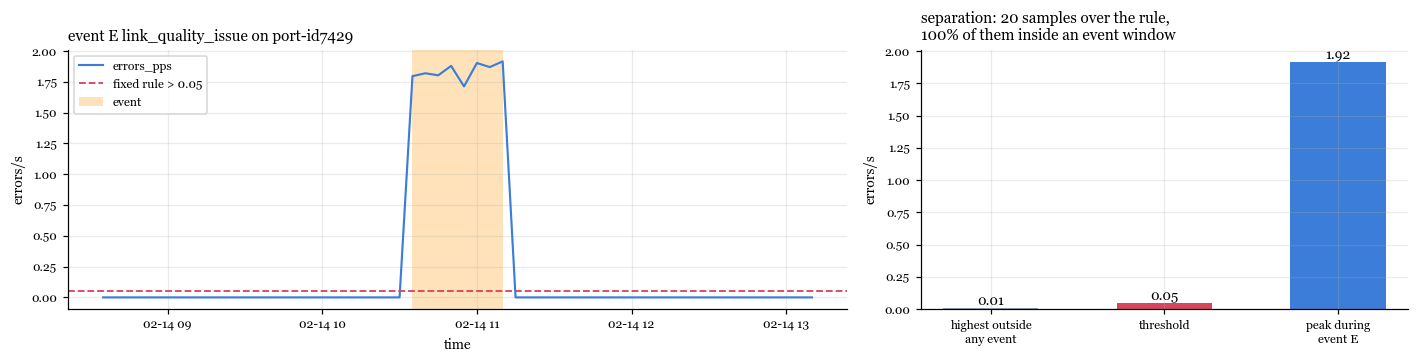

In [15]:
# Event E is the case that every statistical baseline in this notebook misses, because the
# metric carrying it is degenerate. One fixed rule catches it with no tuning at all.
ee = events[events.event_id == "E"].iloc[0]
pad = pd.Timedelta("2h")
w = tel[(tel["port_id"] == ee.port_id)
        & tel["timestamp"].between(ee.start - pad, ee.end + pad)].reset_index(drop=True)

LIMIT = 0.05
normal_max = tel.loc[~tel["is_incident"], "errors_pps"].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].plot(w["timestamp"], w["errors_pps"], color=C["signal"], lw=1.4, label="errors_pps")
axes[0].axhline(LIMIT, color=C["alert"], ls="--", lw=1.2, label=f"fixed rule > {LIMIT}")
shade(axes[0], w["timestamp"], event_window(w, ee))
axes[0].set(ylabel="errors/s", xlabel="time",
            title=f"event E link_quality_issue on {ee.port_id}")
axes[0].legend(loc="upper left")

# Separation: how far the fault sits above the highest error rate seen outside any event.
hot = tel[tel["errors_pps"] > LIMIT]
axes[1].bar(["highest outside\nany event", f"threshold", "peak during\nevent E"],
            [normal_max, LIMIT, w["errors_pps"].max()],
            color=[C["muted"], C["alert"], C["signal"]], width=0.55)
for n, v in enumerate([normal_max, LIMIT, w["errors_pps"].max()]):
    axes[1].text(n, v, f"{v:.3g}", ha="center", va="bottom", fontsize=9)
axes[1].set(ylabel="errors/s",
            title=f"separation: {len(hot)} samples over the rule,\n"
                  f"{100 * tel.loc[tel['errors_pps'] > LIMIT, 'is_incident'].mean():.0f}% "
                  f"of them inside an event window")
fig.tight_layout(); plt.show()

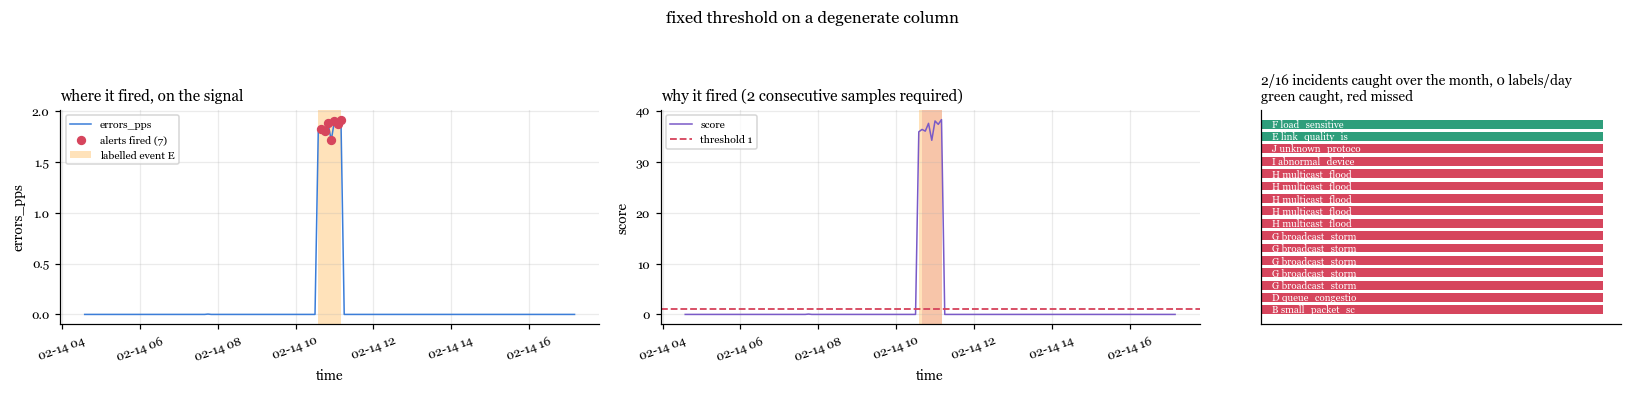

fixed threshold (errors_pps > 0.05) threshold         1 | recall  2/16 |    0.00 labels/day | delay  20.0 min | event E ✓


In [16]:
def fixed_threshold_score(frame, col="errors_pps", limit=0.05):
    """A physical rule rather than a statistical one: how many times over the limit is this.

    Dividing by the limit turns the rule into a score the same rollout can consume, and a
    value of 1.0 is exactly the limit, which makes the threshold self-documenting.
    """
    return frame[col].astype(float) / limit


det_fixed = rollout("fixed threshold (errors_pps > 0.05)", fixed_threshold_score(tel), tel,
                    threshold=1.0)
plot_detection(det_fixed, tel, event_id="E", col="errors_pps",
               title="fixed threshold on a degenerate column")

### 小結

分離度不是勉強，是兩個數量級。沒有 event 的樣本裡 `errors_pps` 最大是 0.0100，event E 的峰值是 1.9167，**中間差 192 倍**，門檻 0.05 落在這個空隙裡。

成績單是整本 notebook 到目前為止最乾淨的一行：**2/16，每天 0.00 筆誤報**，而且是第一個抓到 event E 的方法。左圖上紅點全部落在橘色區塊裡，一顆都沒有落在外面。

它只抓到 2 個，這不是缺點，是分工。它針對的就是統計方法測不到的那一類，而它在那一類上零誤報、零調參。

前提要有人驗：一個有物理基礎的零點，加上背景與故障之間的數量級落差。兩個條件缺一，這條規則就退回「挑一個數字」的老問題。

### 探索練習：fixed threshold 的可用區間

**任務**：把 `LIMIT` 改成 0.01，再改成 0.5，各執行一次。

```python
LIMIT = 0.01
```

觀察：

- 兩個極端各自命中幾筆？
- 有幾筆落在 event window 外面？

**討論**：可用的區間有多寬？區間越寬，這條規則越不需要精細調校。判斷一個 feature 該用 fixed threshold 還是 z-score，目前是人工判斷，沒有自動切換的邏輯，新指標進來就得有人重新判斷一次。五個 port 也共用同一個 `0.05`，背景值不同的 port 值得各自校準。

## 第 10 步：max 這個合成方式的邊界

前九步的每一個分數都是逐欄算出來的，而把多欄併成一個分數的方式是跨欄取最大值。這個合成方式有一個邊界，而它出現的地方跟直覺不同。

第 9 步的 event E 是最乾淨的例子。它的證據在 `errors_pps` 上，而那一欄是 degenerate 的：大半時間剛好等於零，rolling scale 塌到下限，z 量到的幾乎只剩「這一筆非零」，偏離程度已經量不到了。

Lab 01 第 14 步已經量過把這種欄位加進來的價碼，而結果不是「沒有用」。加進去確實抓得到 event E，只是每天要多付幾則 alert。所以真正的問題不是它抓不抓得到，是**加進去之後這個分數還算不算一個分數**。

下面把兩種欄位組合放進同一個合成方式，各用兩種門檻量：一個是本課程一路用到現在的固定 `|z| > 4`，一個是取分數自己的百分位，也就是「每天願意看幾則」換算出來的門檻。

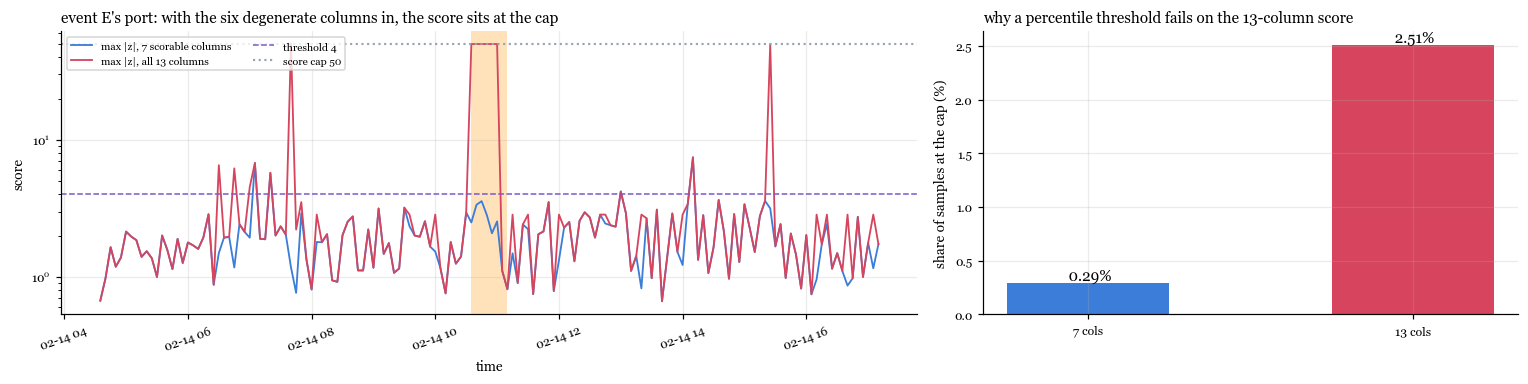

,name,threshold,recall,of,labels_per_day,caught_E
0,max|z| 7 cols @ |z|>4,4.000,15,16,10.87,False
1,max|z| 7 cols @ q=0.995,8.546,15,16,1.70,False
2,max|z| 13 cols @ |z|>4,4.000,16,16,24.14,True
3,max|z| 13 cols @ q=0.995,50.000,0,16,0.00,False


In [17]:
# Two column sets, one composition rule, two ways of choosing the cut. Everything goes
# through the same rollout as every other method in the course, so these land in the ledger
# beside the baselines and are directly comparable to them.
mx_scorable = tel[SCORE_COLS].abs().max(axis=1)
mx_all = tel[ALL_Z].abs().max(axis=1)

ceiling = pd.DataFrame([
    rollout(f"max|z| {tag} @ {cut}", s, tel, **kw).card
    for tag, s in [("7 cols", mx_scorable), ("13 cols", mx_all)]
    for cut, kw in [(f"|z|>{THRESHOLD:g}", {"threshold": THRESHOLD}),
                    (f"q={BUDGET}", {"budget": BUDGET})]
])

eE = events[events.event_id == "E"].iloc[0]
pad = pd.Timedelta("6h")
IDX_E = tel.index[tel["port_id"].eq(eE.port_id)
                  & tel["timestamp"].between(eE.start - pad, eE.end + pad)]
w = tel.loc[IDX_E].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].plot(w["timestamp"], mx_scorable.loc[IDX_E].to_numpy(), color=C["signal"], lw=1.2,
             label="max |z|, 7 scorable columns")
axes[0].plot(w["timestamp"], mx_all.loc[IDX_E].to_numpy(), color=C["alert"], lw=1.2,
             label="max |z|, all 13 columns")
axes[0].axhline(THRESHOLD, color=C["score"], ls="--", lw=1.0, label=f"threshold {THRESHOLD:g}")
axes[0].axhline(MAX_SCORE, color=C["muted"], ls=":", lw=1.4, label=f"score cap {MAX_SCORE:g}")
axes[0].axvspan(eE.start, eE.end, color=C["truth"], alpha=0.3, lw=0)
axes[0].set(ylabel="score", xlabel="time", yscale="log",
            title="event E's port: with the six degenerate columns in, the score sits at the cap")
axes[0].legend(fontsize=7, loc="upper left", ncol=2)
axes[0].tick_params(axis="x", labelrotation=20)

sat = pd.Series({"7 cols": float((mx_scorable >= MAX_SCORE - 1e-6).mean()),
                 "13 cols": float((mx_all >= MAX_SCORE - 1e-6).mean())})
axes[1].bar(range(2), sat.to_numpy() * 100, color=[C["signal"], C["alert"]], width=0.5)
for n, v in enumerate(sat):
    axes[1].text(n, v * 100, f" {v:.2%}", ha="center", va="bottom", fontsize=10)
axes[1].set_xticks(range(2), sat.index)
axes[1].set(ylabel="share of samples at the cap (%)",
            title="why a percentile threshold fails on the 13-column score")
fig.tight_layout(); plt.show()

display(ceiling[["name", "threshold", "recall", "of", "labels_per_day", "caught_E"]])

### 小結

固定門檻那兩列的結論很平淡：加進 degenerate 六欄，recall 從 15 升到 16，每日越線筆數從 10.87 升到 24.14。多抓一個 event，代價是 2.2 倍的噪音。這是一筆可以簽核的交易，跟 Lab 01 第 14 步量到的一樣。

**壞掉的是另外一列。** 取 q=0.995 當門檻時，7 欄那組的門檻落在 8.55，13 欄那組落在 50.00，也就是分數的上限本身，於是沒有任何一筆樣本超過它，recall 是 0。

原因在 左圖：加進 degenerate 六欄之後，有 2.51% 的樣本頂在上限，所以 99% 與 99.5% 兩個分位數都剛好等於 50。尾端大半黏在同一個值上的分數還可以當規則用，卻已經無法排序。 排序、分位數門檻、PR 曲線在它上面全部失去意義，而第 18 步之後每一格都建立在「分數可以排序」這個前提上。

所以這一步要換掉的不是欄位，是合成方式。max 要求每一欄先各自變成可比較的分數，degenerate 欄位過不了的正是這一關。下一步換一類不需要逐欄估 scale 的方法。

## 第 11 步：Isolation Forest

前一步的困境不在資料，在合成方式。max 要求每一欄先各自變成可比較的分數，而那一步正是 degenerate 欄位過不了的。

換一類方法：**不逐欄計分，直接在多維空間裡問這個點有多孤立**。這樣就不必為任何一欄估計 scale，degenerate 的欄位可以照原樣放進去。

Isolation Forest 的想法很省事。隨機挑一欄、隨機挑一個切點，反覆切下去直到每個點都被單獨隔開。孤立的點平均需要比較少刀就切出來了，所以「平均切幾刀」就是分數。它不假設任何分佈，也不需要標籤。

模型只用前半個月訓練，整個月都拿來計分。這樣後半個月的成績量的才是沒看過的資料。

順帶把一個常見的誤會量出來。`contamination` 看起來像敏感度旋鈕，實際上 `score_samples()` 的輸出完全不受它影響，它只決定 `predict()` 把哪一條線當成正負的分界。下面把它掃過五個數量級，看分數動不動。


usable rows 43,185 of 43,200 | train 21,585 rows before 2026-02-15 (0.43% of them inside a labelled event)


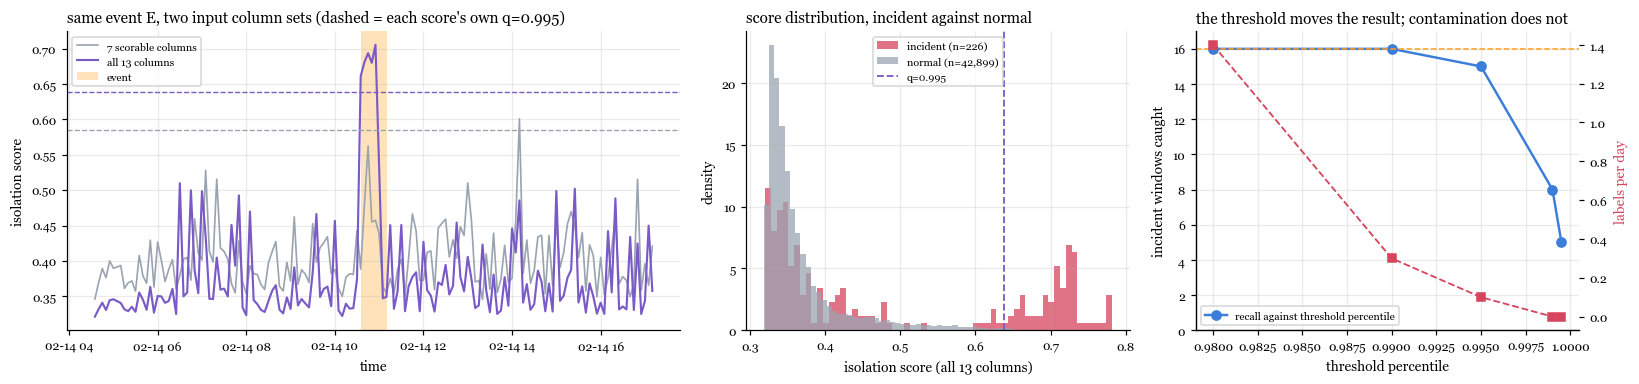

,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
0,IsolationForest 7 cols,0.5853,15,16,1.77,5.0,False
1,IsolationForest 13 cols,0.6384,15,16,0.10,5.0,True


contamination swept 0.0001 to 0.4; score_samples p99.9 takes 1 distinct value(s):


,contamination,score_p999
0,0.0001,0.713219
1,0.0010,0.713219
2,0.0100,0.713219
3,0.1000,0.713219
4,0.4000,0.713219


,budget_q,threshold,recall,of,labels_per_day,caught_E
0,0.9800,0.5725,16,16,1.4,True
1,0.9900,0.6102,16,16,0.3,True
2,0.9950,0.6384,15,16,0.1,True
3,0.9990,0.7132,8,16,0.0,False
4,0.9995,0.7290,5,16,0.0,False


In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Rows before the first baseline exists have NaN z values and cannot be scored by a model
# that has no notion of missing input, so they are dropped from the model frame only.
usable = tel[ALL_Z].notna().all(axis=1)
SPLIT = SPAN[0] + (SPAN[1] - SPAN[0]) / 2
train_mask = usable & (tel["timestamp"] < SPLIT)
CONTAM = 0.01

print(f"usable rows {int(usable.sum()):,} of {len(tel):,} | "
      f"train {int(train_mask.sum()):,} rows before {SPLIT:%Y-%m-%d} "
      f"({tel.loc[train_mask, 'is_event'].mean():.2%} of them inside a labelled event)")


def fit_iforest(cols, contamination=CONTAM, seed=0, n_estimators=200, max_samples="auto"):
    """Higher score means more anomalous, so the sklearn convention is negated once here."""
    m = IsolationForest(n_estimators=n_estimators, max_samples=max_samples,
                        contamination=contamination, random_state=seed,
                        n_jobs=-1).fit(tel.loc[train_mask, cols])
    s = pd.Series(np.nan, index=tel.index)
    s[usable] = -m.score_samples(tel.loc[usable, cols])
    return s


iso_scorable = fit_iforest(SCORE_COLS)
iso_all = fit_iforest(ALL_Z)

iso_card = pd.DataFrame([rollout(name, s, tel, budget=BUDGET).card
                         for name, s in [("IsolationForest 7 cols", iso_scorable),
                                         ("IsolationForest 13 cols", iso_all)]])

# Two sweeps side by side. contamination is the one everybody reaches for; the alert
# budget is the one that actually moves the outcome.
contam_sweep = pd.DataFrame([
    {"contamination": c, "score_p999": float(np.nanquantile(fit_iforest(ALL_Z, contamination=c),
                                                            0.999))}
    for c in (0.0001, 0.001, 0.01, 0.1, 0.4)])
budget_sweep = pd.DataFrame([
    {"budget_q": q, **rollout(f"IForest q={q}", iso_all, tel, budget=q, keep=False).card}
    for q in (0.98, 0.99, 0.995, 0.999, 0.9995)])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), gridspec_kw={"width_ratios": [1.6, 1, 1]})

axes[0].plot(w["timestamp"], iso_scorable.loc[IDX_E].to_numpy(), color=C["muted"], lw=1.1,
             label="7 scorable columns")
axes[0].plot(w["timestamp"], iso_all.loc[IDX_E].to_numpy(), color=C["score"], lw=1.4,
             label="all 13 columns")
for s, colour in [(iso_scorable, C["muted"]), (iso_all, C["score"])]:
    axes[0].axhline(np.nanquantile(s, BUDGET), color=colour, ls="--", lw=0.9)
shade(axes[0], w["timestamp"], event_window(w, eE))
axes[0].set(ylabel="isolation score", xlabel="time",
            title=f"same event E, two input column sets (dashed = each score's own q={BUDGET})")
axes[0].legend(fontsize=7, loc="upper left")

for name, m, colour in [("incident", tel["is_incident"], C["alert"]),
                        ("normal", ~tel["is_event"], C["muted"])]:
    v = iso_all[usable & m].dropna()
    axes[1].hist(v, bins=60, density=True, alpha=0.75, color=colour,
                 label=f"{name} (n={len(v):,})")
axes[1].axvline(np.nanquantile(iso_all, BUDGET), color=C["score"], ls="--", lw=1.2,
                label=f"q={BUDGET}")
axes[1].set(xlabel="isolation score (all 13 columns)", ylabel="density",
            title="score distribution, incident against normal")
axes[1].legend(fontsize=7)

axes[2].plot(budget_sweep["budget_q"], budget_sweep["recall"], marker="o", ms=6,
             color=C["signal"], lw=1.6, label="recall against threshold percentile")
axes[2].axhline(len(incidents), color=C["truth"], ls="--", lw=1.0)
axes[2].set(xlabel="threshold percentile", ylabel="incident windows caught",
            ylim=(0, len(incidents) + 1),
            title="the threshold moves the result; contamination does not")
tw = axes[2].twinx(); tw.grid(False)
tw.plot(budget_sweep["budget_q"], budget_sweep["labels_per_day"], marker="s", ms=5,
        color=C["alert"], lw=1.2, ls="--")
tw.set_ylabel("labels per day", color=C["alert"])
axes[2].legend(fontsize=7, loc="lower left")
fig.tight_layout(); plt.show()

display(iso_card)
print(f"contamination swept {contam_sweep['contamination'].min():g} to "
      f"{contam_sweep['contamination'].max():g}; score_samples p99.9 takes "
      f"{contam_sweep['score_p999'].nunique()} distinct value(s):")
display(contam_sweep)
display(budget_sweep[["budget_q", "threshold", "recall", "of", "labels_per_day", "caught_E"]])

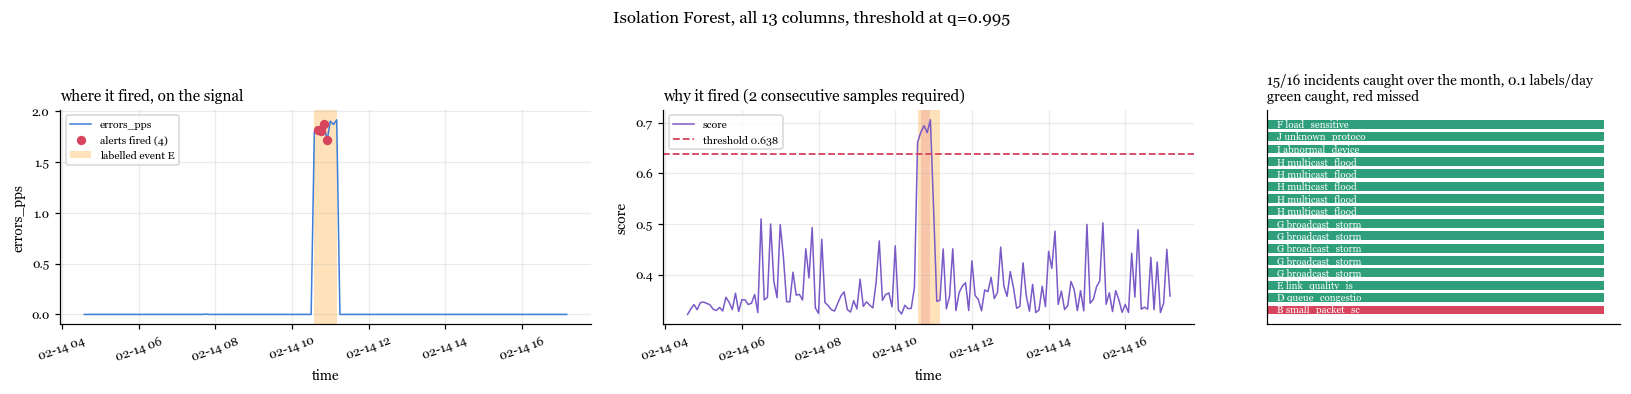

IsolationForest 13 cols    threshold    0.6384 | recall 15/16 |    0.10 labels/day | delay   5.0 min | event E ✓


In [19]:
det_iso = rollout("IsolationForest 13 cols", iso_all, tel, budget=BUDGET)
plot_detection(det_iso, tel, event_id="E", col="errors_pps",
               title="Isolation Forest, all 13 columns, threshold at q=0.995")

### 小結

同一個模型，輸入欄位不同，結果就不同：7 欄那組漏掉 event E，13 欄那組抓到，而後者每天只產生 0.10 則背景越線，整個月 3 則。

代價在同一張表上：13 欄那組在 q=0.995 這個門檻下 recall 也是 15，它換掉的是另一個 window，不是純賺。右圖顯示把門檻放寬到 q=0.98 就變成 16/16，每天 1.4 則，仍然比第 10 步的固定門檻版本安靜得多。

左圖的兩條線說明了機制。degenerate 欄位的 z 在 event E 期間確實動了，而 Isolation Forest 從來不除以任何一欄的 scale，所以那個「z 爆表但不帶資訊」的問題對它不存在。它處理的只是一個在十三維空間裡位置罕見的點。

### 探索練習：真正改變分數的參數

`contamination` 從 0.0001 掃到 0.4，`score_samples()` 的 p99.9 一動也不動，因為它只寫進 `offset_`，而 `offset_` 只有 `predict()` 與 `decision_function()` 會用到。把它當敏感度旋鈕來調，調的是一個不存在的東西。

會改變分數的是森林本身的形狀。

**任務**：改動樹的數量與每棵樹取用的樣本數。

```python
iso_small = fit_iforest(ALL_Z, n_estimators=20)          # too few trees, unstable score
iso_wide  = fit_iforest(ALL_Z, max_samples=4096)         # each tree sees more, finer boundary
```

觀察：

- `n_estimators=20` 換三個 `seed` 各執行一次，recall 差幾個？200 棵的時候呢？
- `max_samples` 從預設的 256 拉到 4096，中圖兩堆分佈的重疊變多還是變少？

**討論**：預設的 `max_samples=256` 意思是每棵樹只看 256 列，這在 21,585 列的訓練資料上是很小的一撮。它讓每棵樹便宜且彼此獨立，代價是單棵樹對局部結構幾乎沒有解析度，全靠 200 棵平均起來。這也是為什麼 Isolation Forest 對高維稀疏的資料表現不穩：隨機挑到有訊號那一欄的機率，隨著欄位變多而下降。

## 第 12 步：One-Class SVM 與 Local Outlier Factor

同一個想法有其他做法，而它們對「正常長什麼樣」的假設不同。

**One-Class SVM** 在特徵空間裡畫一條把絕大多數訓練資料包起來的邊界，邊界外面就是異常。RBF kernel 讓這條邊界可以是彎的。它有兩個旋鈕：`nu` 是允許留在邊界外的訓練資料比例，`gamma` 決定邊界能彎到什麼程度。它吃距離，所以**輸入一定要先標準化**，否則尺度大的那一欄會獨自決定邊界的形狀。

**Local Outlier Factor** 問的是另一個問題：這個點的鄰居有多密集，跟它的鄰居的鄰居比起來如何。所以它抓得到「全域看不極端，但在自己那一小群裡很孤立」的點。`n_neighbors` 決定「鄰域」有多大。

三個模型的假設不同，所以它們不會挑出同一批點。第 13 步會量它們的分歧有多大。

這一步順便量一件實務上會問的事：這些模型在這個資料量上跑多久。

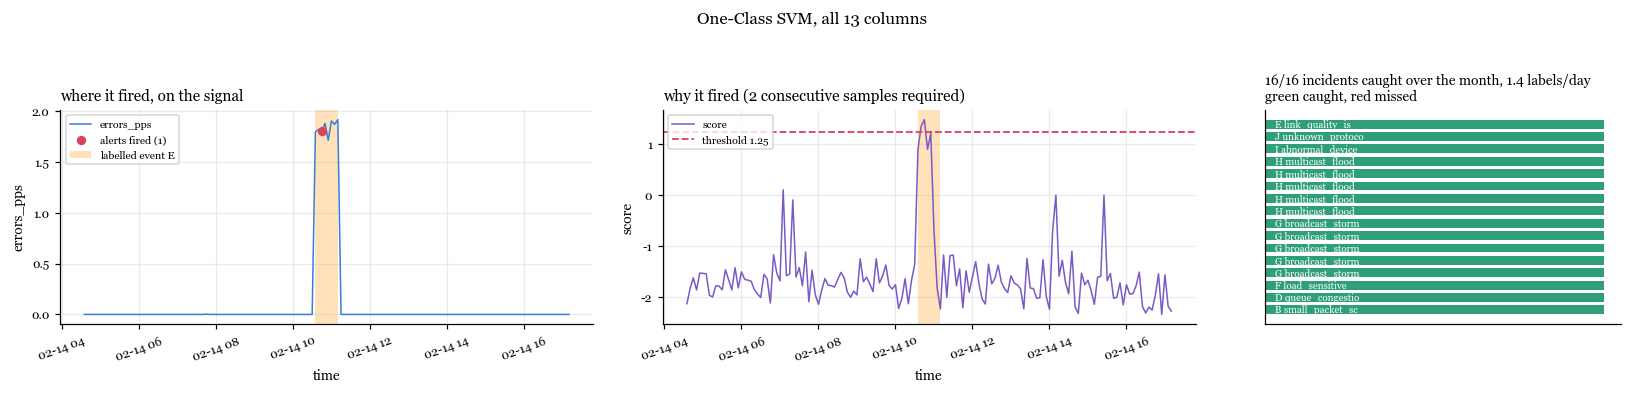

OneClassSVM 13 cols        threshold     1.247 | recall 16/16 |    1.40 labels/day | delay   5.0 min | event E ✓


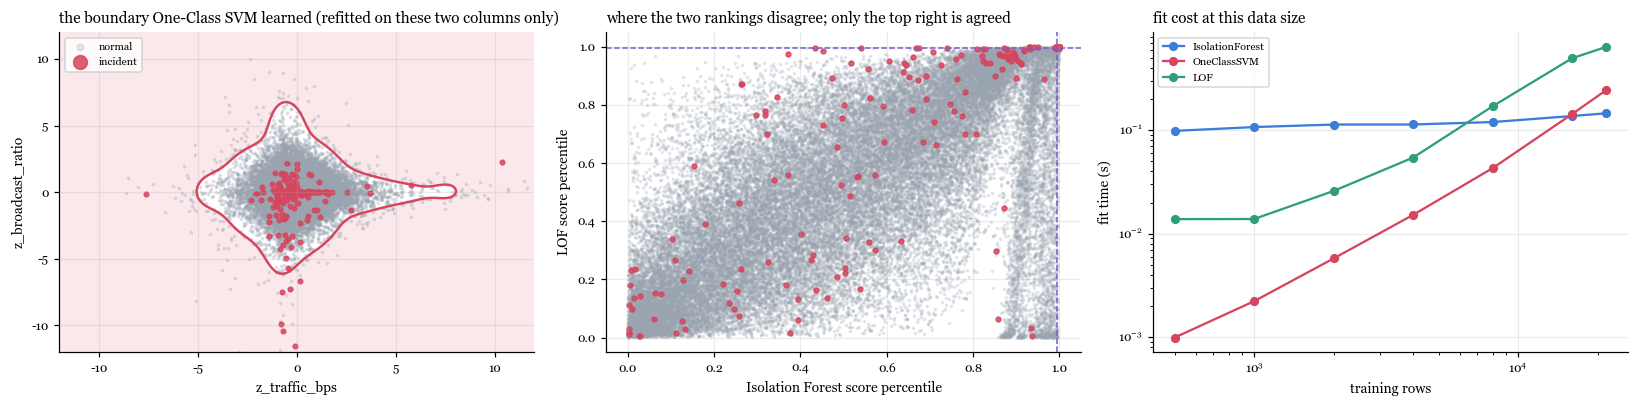

,IsolationForest,OneClassSVM,LOF
500,0.098,0.001,0.014
1000,0.107,0.002,0.014
2000,0.113,0.006,0.026
4000,0.113,0.015,0.054
8000,0.120,0.043,0.170
16000,0.137,0.143,0.495
21585,0.146,0.245,0.639


In [20]:
import time
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor


def fit_boundary(cols, model_factory):
    """Standardise on the training half, then score the whole month with the same scaler.

    Fitting the scaler on the training half only is not a formality: fitting it on
    everything would let the events being scored influence the scale they are judged by.
    """
    sc = StandardScaler().fit(tel.loc[train_mask, cols])
    m = model_factory().fit(sc.transform(tel.loc[train_mask, cols]))
    s = pd.Series(np.nan, index=tel.index)
    s[usable] = -m.decision_function(sc.transform(tel.loc[usable, cols]))
    return s, m, sc


ocsvm_all, ocsvm_model, ocsvm_scaler = fit_boundary(
    ALL_Z, lambda: OneClassSVM(kernel="rbf", nu=CONTAM, gamma="scale"))
lof_all, _, _ = fit_boundary(
    ALL_Z, lambda: LocalOutlierFactor(n_neighbors=20, contamination=CONTAM,
                                      novelty=True, n_jobs=-1))
ocsvm_scorable, _, _ = fit_boundary(
    SCORE_COLS, lambda: OneClassSVM(kernel="rbf", nu=CONTAM, gamma="scale"))
lof_scorable, _, _ = fit_boundary(
    SCORE_COLS, lambda: LocalOutlierFactor(n_neighbors=20, contamination=CONTAM,
                                           novelty=True, n_jobs=-1))

# Same rollout as every other method, so these four join the ledger rather than appearing
# only inside this step's comparison table.
det_ocsvm = rollout("OneClassSVM 13 cols", ocsvm_all, tel, budget=BUDGET)
det_lof = rollout("LOF 13 cols", lof_all, tel, budget=BUDGET)
rollout("OneClassSVM 7 cols", ocsvm_scorable, tel, budget=BUDGET)
rollout("LOF 7 cols", lof_scorable, tel, budget=BUDGET)

plot_detection(det_ocsvm, tel, event_id="E", col="errors_pps",
               title="One-Class SVM, all 13 columns")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# A. the boundary itself, on the two columns that carry most of the evidence. The model
# below is refitted on just those two so the contour is the real decision function rather
# than a projection of a 13-dimensional one, which would not be a boundary at all.
PAIR = ["z_traffic_bps", "z_broadcast_ratio"]
sc2 = StandardScaler().fit(tel.loc[train_mask, PAIR])
m2 = OneClassSVM(kernel="rbf", nu=CONTAM, gamma="scale").fit(sc2.transform(tel.loc[train_mask, PAIR]))
lim = 12
gx, gy = np.meshgrid(np.linspace(-lim, lim, 220), np.linspace(-lim, lim, 220))
zz = m2.decision_function(sc2.transform(np.c_[gx.ravel(), gy.ravel()])).reshape(gx.shape)
axes[0].contourf(gx, gy, zz, levels=[zz.min(), 0], colors=[C["alert"]], alpha=0.12)
axes[0].contour(gx, gy, zz, levels=[0], colors=[C["alert"]], linewidths=1.6)
bg = usable & ~tel["is_event"]
axes[0].scatter(tel.loc[bg, PAIR[0]], tel.loc[bg, PAIR[1]], s=2, color=C["muted"],
                alpha=0.25, label="normal")
inc = usable & tel["is_incident"]
axes[0].scatter(tel.loc[inc, PAIR[0]], tel.loc[inc, PAIR[1]], s=9, color=C["alert"],
                alpha=0.85, label="incident")
axes[0].set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel=PAIR[0], ylabel=PAIR[1],
            title="the boundary One-Class SVM learned (refitted on these two columns only)")
axes[0].legend(fontsize=7, loc="upper left", markerscale=3)

# B. where the two families disagree. Both axes are percentile ranks, because the raw
# scores live on incomparable scales and a scatter of them would say nothing.
rk = lambda s: s.rank(pct=True)
axes[1].scatter(rk(iso_all)[bg], rk(lof_all)[bg], s=2, color=C["muted"], alpha=0.2)
axes[1].scatter(rk(iso_all)[inc], rk(lof_all)[inc], s=10, color=C["alert"], alpha=0.85)
axes[1].axvline(BUDGET, color=C["score"], ls="--", lw=1.0)
axes[1].axhline(BUDGET, color=C["score"], ls="--", lw=1.0)
axes[1].set(xlabel="Isolation Forest score percentile", ylabel="LOF score percentile",
            title="where the two rankings disagree; only the top right is agreed")

# C. what these models cost to fit at this data size.
sizes, times = [500, 1000, 2000, 4000, 8000, 16000, int(train_mask.sum())], []
Xtr = StandardScaler().fit_transform(tel.loc[train_mask, ALL_Z])
rng = np.random.default_rng(0)
for n in sizes:
    idx = rng.choice(len(Xtr), size=min(n, len(Xtr)), replace=False)
    row = {}
    for nm, mk in [("IsolationForest", lambda: IsolationForest(n_estimators=200, n_jobs=-1,
                                                              random_state=0)),
                   ("OneClassSVM", lambda: OneClassSVM(kernel="rbf", nu=CONTAM, gamma="scale")),
                   ("LOF", lambda: LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1))]:
        t0 = time.perf_counter()
        mk().fit(Xtr[idx])
        row[nm] = time.perf_counter() - t0
    times.append(row)
times = pd.DataFrame(times, index=[min(n, len(Xtr)) for n in sizes])
for nm, colour in zip(times.columns, [C["signal"], C["alert"], C["peer"]]):
    axes[2].plot(times.index, times[nm], marker="o", ms=5, lw=1.5, color=colour, label=nm)
axes[2].set(xscale="log", yscale="log", xlabel="training rows", ylabel="fit time (s)",
            title="fit cost at this data size")
axes[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

display(times.round(3))

### 小結

左圖是 One-Class SVM 跟前面所有方法最大的差別。它學到的是一條**封閉曲線**，而 z-score 家族學到的永遠是每一軸各自的一段區間，也就是一個矩形。紅色的 incident 點大多落在邊界外，但有一整叢貼著邊界內側，那些就是分數排在 99.5 百分位以下、不會被標記的樣本。

中圖顯示兩個模型的排名差異不小。右上角是兩邊都標記的那一小塊，左上與右下各有一批只有其中一邊標記的樣本。兩者標記的樣本不同，第 13 步會看到它們抓到的 event 卻幾乎相同。

右圖是選型時真正會被問到的問題。Isolation Forest 的成本幾乎不隨資料量成長，因為每棵樹只抽固定筆數；One-Class SVM 與 LOF 都隨資料量明顯上升。在 21,585 列上三者都在一秒內完成，這個差距還不構成選擇的理由。資料量再大兩個數量級的時候它才會，而那時候 One-Class SVM 需要的是 `SGDOneClassSVM` 或 `Nystroem` 近似，不是原本這個。

## 第 13 步：四種偵測器，同一張成績單

四個偵測器，兩種輸入欄位組合，同一個確認規則、同一個 recall 分母、同一個每日成本定義。門檻一律取各自分數的同一個百分位，這樣比的是「在相同的值班負擔下抓到多少」，而不是誰的分數比較大。

要回答的是兩件事：換一個模型，成績差多少；換掉輸入欄位，成績又差多少。

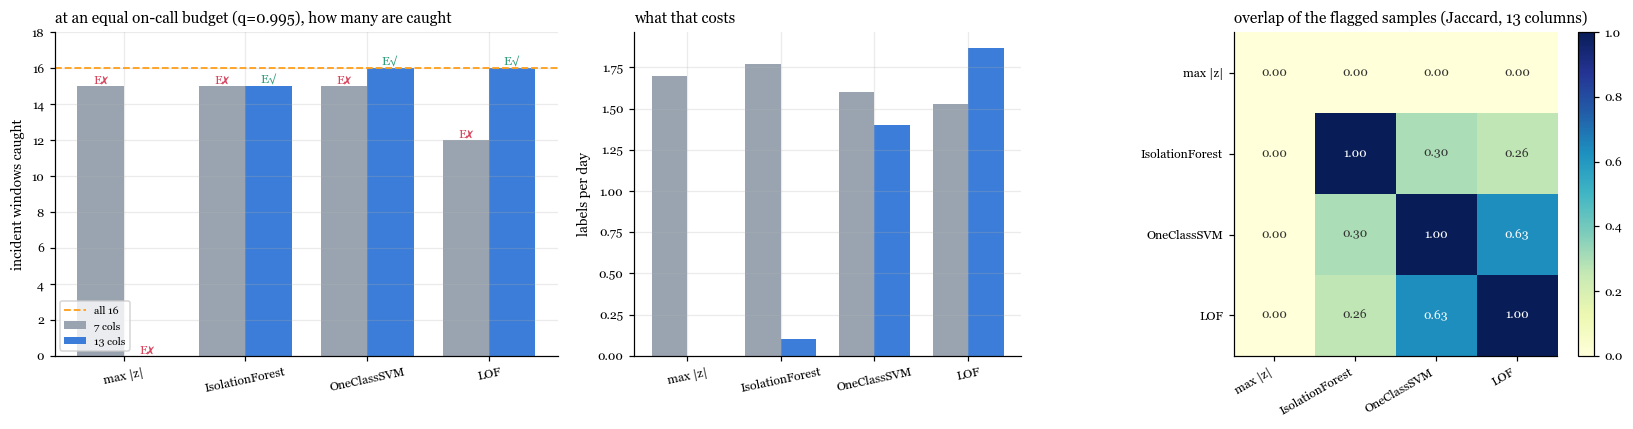

,model,columns,recall,of,labels_per_day,median_delay_min,caught_E
0,max |z|,7 cols,15,16,1.70,5.0,False
1,max |z|,13 cols,0,16,0.00,NaN,False
2,IsolationForest,7 cols,15,16,1.77,5.0,False
3,IsolationForest,13 cols,15,16,0.10,5.0,True
4,OneClassSVM,7 cols,15,16,1.60,5.0,False
5,OneClassSVM,13 cols,16,16,1.40,5.0,True
6,LOF,7 cols,12,16,1.53,5.0,False
7,LOF,13 cols,16,16,1.87,5.0,True


In [21]:
DETECTORS = {
    ("max |z|", "7 cols"): mx_scorable, ("max |z|", "13 cols"): mx_all,
    ("IsolationForest", "7 cols"): iso_scorable, ("IsolationForest", "13 cols"): iso_all,
    ("OneClassSVM", "7 cols"): ocsvm_scorable, ("OneClassSVM", "13 cols"): ocsvm_all,
    ("LOF", "7 cols"): lof_scorable, ("LOF", "13 cols"): lof_all,
}

# Same rollout, same budget, so the only thing that differs between rows is the detector
# and the columns it was given. keep=False because steps 10 to 12 already registered every
# one of these; re-registering would put the same method on the ledger plot twice.
board = pd.DataFrame([{"model": m, "columns": c,
                       **rollout(f"{m} {c}", s, tel, budget=BUDGET, keep=False).card}
                      for (m, c), s in DETECTORS.items()])

# Agreement on the flagged samples. Two detectors can post the same recall while flagging
# almost disjoint sets, and only this number shows it.
top = {k: set(np.flatnonzero((s > np.nanquantile(s.dropna(), BUDGET)).fillna(False).to_numpy()))
       for k, s in DETECTORS.items()}
keys = [k for k in DETECTORS if k[1] == "13 cols"]
jac = pd.DataFrame([[len(top[a] & top[b]) / max(len(top[a] | top[b]), 1) for b in keys]
                    for a in keys], index=[k[0] for k in keys], columns=[k[0] for k in keys])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0), gridspec_kw={"width_ratios": [1.3, 1, 1.3]})
models = board["model"].unique().tolist()
x = np.arange(len(models))
for off, cols, colour in [(-0.19, "7 cols", C["muted"]), (0.19, "13 cols", C["signal"])]:
    d = board[board["columns"] == cols].set_index("model").reindex(models)
    axes[0].bar(x + off, d["recall"], width=0.38, color=colour, label=cols)
    for n, t in enumerate(d.itertuples()):
        axes[0].text(x[n] + off, t.recall, "E✓" if t.caught_E else "E✗", ha="center",
                     va="bottom", fontsize=8, color=C["peer"] if t.caught_E else C["alert"])
    axes[1].bar(x + off, d["labels_per_day"], width=0.38, color=colour)
axes[0].axhline(len(incidents), color=C["truth"], ls="--", lw=1.2, label=f"all {len(incidents)}")
axes[0].set_xticks(x, models, fontsize=8, rotation=12)
axes[0].set(ylabel="incident windows caught", ylim=(0, len(incidents) + 2),
            title=f"at an equal on-call budget (q={BUDGET}), how many are caught")
axes[0].legend(fontsize=7, loc="lower left")
axes[1].set_xticks(x, models, fontsize=8, rotation=12)
axes[1].set(ylabel="labels per day", title="what that costs")

im = axes[2].imshow(jac.to_numpy(), cmap="YlGnBu", vmin=0, vmax=1)
axes[2].set_xticks(range(len(jac)), jac.columns, rotation=30, ha="right", fontsize=8)
axes[2].set_yticks(range(len(jac)), jac.index, fontsize=8)
for a in range(len(jac)):
    for b in range(len(jac)):
        axes[2].text(b, a, f"{jac.iat[a, b]:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if jac.iat[a, b] > 0.55 else "#333333")
axes[2].grid(False)
axes[2].set_title("overlap of the flagged samples (Jaccard, 13 columns)")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
fig.tight_layout(); plt.show()

display(board[["model", "columns", "recall", "of", "labels_per_day",
               "median_delay_min", "caught_E"]])

### 小結

四種偵測器的成績接近，換掉輸入欄位之後才出現明顯差異。

四個偵測器在相同的值班負擔下成績接近，而 右圖顯示它們標記的樣本重疊得並不多。這兩件事合起來的意思是：它們挑的點不同，但抓到的 event 相同。event 層級的成績對點層級的分歧不敏感，因為一個 event 有很多筆樣本，任何一筆被標記就算抓到。

真正動了成績的是輸入欄位。第 10 步的 max 加進 degenerate 六欄之後直接失效，而同樣那六欄輸入多變量模型之後，event E 被抓到了。差別在於 max 需要每一欄先各自標準化，而密度型的模型不需要。

所以第 9 步那條固定規則不是唯一的解法，它是「人工為單一指標挑一條線」，而這裡是「讓模型自己在多維空間裡找邊界」。兩者都有效，維護成本不同：前者每加一個指標就要有人再挑一次，後者要有人定期確認訓練資料還代表得了現在的正常。

下面回到告警層。第 14 步之後與計分方式無關，所以繼續用前九步量過的 `score_max`。

### 探索練習：把模型分數接上告警層

第 14 步之後的每一格處理的是 score 之後的事：確認、抑制、嚴重度、評估。那一段完全不在乎分數是怎麼算出來的，所以換一個偵測器不需要改動任何一格。

**任務**：把 `score_max` 換成模型分數，然後直接往下跑。

```python
tel["score_max"] = ocsvm_all                      # or iso_all, lof_all
THRESHOLD = float(np.nanquantile(ocsvm_all, 0.995))   # the threshold must change units too
```

觀察：

- 第 17 步的 scorecard 四個數字各變成多少？
- 第 19 步的 recall 高原還在同一個位置嗎？
- 第 20 步的成本最佳解換手的 $R$ 值往哪邊移？

**討論**：`THRESHOLD` 必須跟著換，因為模型分數不在 sigma 這個單位上，4.0 對它沒有意義。這件事在正式部署裡是個持續的負擔：z-score 的門檻可以跟維運人員解釋成「離正常四個標準差」，isolation score 的 0.59 解釋不了，只能說「這是我們每天願意看的量」。可解釋性的差距不在準確度上，在調校的對話裡。

本課程後面繼續用 `score_max`，因為它前面每一步都被量過，換掉會讓第 14 步之後的每一個數字都要重講一次。

## 第 14 步：多 feature 合成 score_max

跨獨立 feature 取最大偏差，而不是平均或加總。理由是 Lab 01 第 12 步的 correlation matrix：高度相關的 feature 分開計分只是把同一份證據數兩次；取最大值讓任何一個 feature 單獨就能超過門檻，而不會被其他不相關的 feature 稀釋掉。

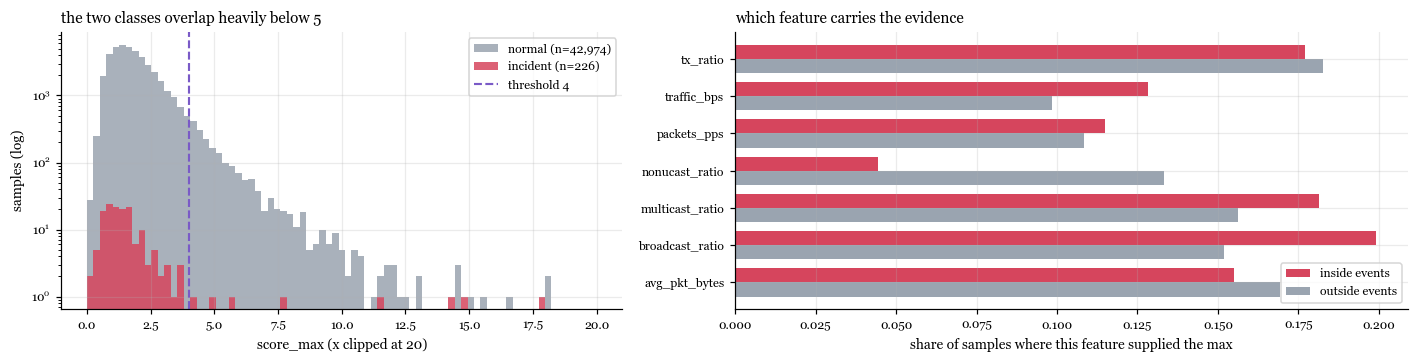

In [22]:
# SCORE_COLS came from the spec in step 1, so this cell no longer restates the list.
# Step 10 measured what adding a degenerate column here would do to the max.
tel["score_max"] = tel[SCORE_COLS].abs().max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1, 1.2]})
bins = np.linspace(0, 20, 80)
axes[0].hist(tel.loc[~tel["is_incident"], "score_max"], bins=bins, color=C["muted"],
             alpha=0.85, log=True, label=f"normal (n={int((~tel['is_incident']).sum()):,})")
axes[0].hist(tel.loc[tel["is_incident"], "score_max"], bins=bins, color=C["alert"],
             alpha=0.85, log=True, label=f"incident (n={int(tel['is_incident'].sum()):,})")
axes[0].axvline(THRESHOLD, color=C["score"], ls="--", lw=1.4, label=f"threshold {THRESHOLD:g}")
axes[0].set(xlabel="score_max (x clipped at 20)", ylabel="samples (log)",
            title="the two classes overlap heavily below 5")
axes[0].legend()

# Which feature actually supplied the max, inside events versus outside.
# The first samples of each port have no baseline yet, so their scores are all NaN and
# no feature "won". Fill with -1 so idxmax is defined, then drop those rows from the count.
ready = tel["score_max"].notna()
winner = tel[SCORE_COLS].abs().fillna(-1).idxmax(axis=1).str.replace("z_", "", regex=False)
inside = winner[ready & tel["is_incident"]].value_counts(normalize=True)
outside = winner[ready & ~tel["is_incident"]].value_counts(normalize=True)
order = inside.index.union(outside.index)
y = np.arange(len(order))
axes[1].barh(y + 0.19, inside.reindex(order).fillna(0), height=0.38,
             color=C["alert"], label="inside events")
axes[1].barh(y - 0.19, outside.reindex(order).fillna(0), height=0.38,
             color=C["muted"], label="outside events")
axes[1].set_yticks(y, order, fontsize=8)
axes[1].set(xlabel="share of samples where this feature supplied the max",
            title="which feature carries the evidence")
axes[1].legend()
fig.tight_layout(); plt.show()

### 小結

左圖的重疊比看起來還嚴重。正常樣本的 p99 是 5.83，**而 event 樣本的中位數只有 1.75**。也就是說超過一半的 event 樣本，分數比 1% 的正常樣本還低。

沒有任何一個 threshold 能把這兩堆切開，這不是門檻沒調好，是分數本身的資訊量就到這裡。後面的 confirmation 與 policy 兩層不是裝飾，是這張圖逼出來的。

右圖顯示 event 內外供應最大值的 feature 幾乎是同一組，最大差距只有兩個百分點。單一 feature 的貢獻在這個合成方式下被攤平了。

### 探索練習：最大值與平均

**任務**：把 `score_max` 的合成方式改成平均。

```python
tel["score_max"] = tel[SCORE_COLS].abs().mean(axis=1)
```

觀察：

- 左圖裡兩個分佈的重疊變多還是變少？
- 右圖的「誰供應了最大值」還有意義嗎？

**討論**：平均會讓單一 feature 的強證據被其他沒有反應的 feature 稀釋。`SCORE_COLS` 這份名單本身就是參數，它來自 Lab 01 的 `SCORABLE`，加一欄減一欄都會動到後面每一個數字。

## 第 15 步：score 到決策：連續 N 筆 confirmation

單一樣本跨過 threshold 仍然只是一個嘈雜的資料點。要求違規持續 N 個連續樣本，濾掉跨過就立刻回落的雜訊。

代價是確定的：每多要求一個樣本，就多一個取樣週期的 detection delay，$(N-1) \times$ cadence，沒有機率成分。而且 Lab 01 量到最短 event 只有 8 筆，N 不能接近那個數字。

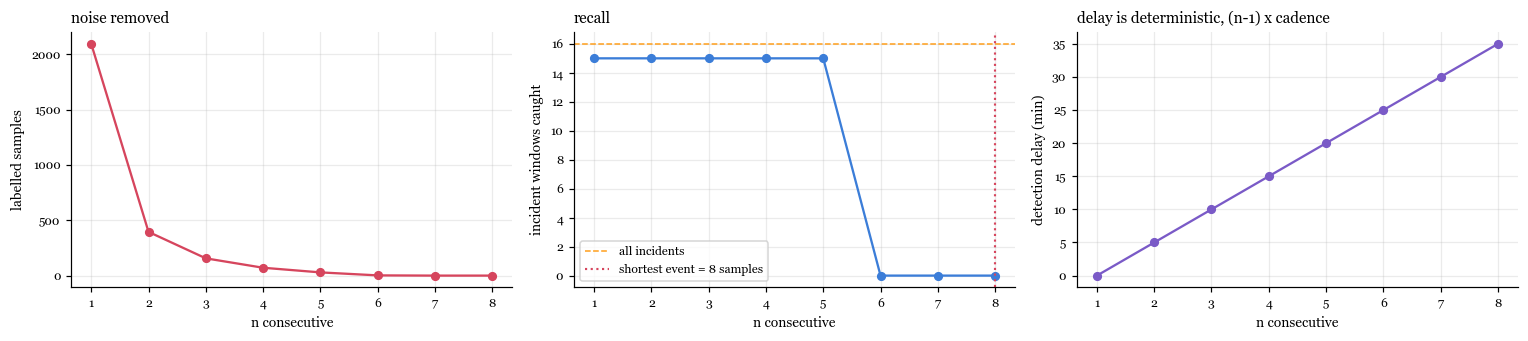

In [23]:
def confirm(score, threshold, n_consecutive, group):
    """Threshold a score, then require n consecutive breaches within the same port.

    Layer 1 to layer 2: a continuous score becomes a binary decision. The shift is grouped
    so a run can never straddle two ports, which would confirm an event that never happened.
    """
    breach = (score > threshold).fillna(False)
    label = breach.copy()
    for k in range(1, n_consecutive):
        label &= breach.groupby(group).shift(k).fillna(False)
    return breach, label


tel["breach"], tel["label"] = confirm(tel["score_max"], THRESHOLD, N_CONSEC, tel["port_id"])

# Sweep N to price the trade directly: how many breaches survive, and what it costs in delay.
rows = []
for n in range(1, 9):
    _, lab = confirm(tel["score_max"], THRESHOLD, n, tel["port_id"])
    caught = sum(lab[(tel["port_id"] == e.port_id)
                     & tel["timestamp"].between(e.start, e.end)].any()
                 for e in incidents.itertuples())
    rows.append({"n": n, "labels": int(lab.sum()), "caught": caught,
                 "delay_min": (n - 1) * CADENCE / 60})
conf = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(conf["n"], conf["labels"], marker="o", ms=5, color=C["alert"])
axes[0].set(xlabel="n consecutive", ylabel="labelled samples", title="noise removed")
axes[1].plot(conf["n"], conf["caught"], marker="o", ms=5, color=C["signal"])
axes[1].axhline(len(incidents), color=C["truth"], ls="--", lw=1.0, label="all incidents")
axes[1].axvline(int(events.n.min()), color=C["alert"], ls=":", lw=1.4,
                label=f"shortest event = {int(events.n.min())} samples")
axes[1].set(xlabel="n consecutive", ylabel="incident windows caught", title="recall")
axes[1].legend()
axes[2].plot(conf["n"], conf["delay_min"], marker="o", ms=5, color=C["score"])
axes[2].set(xlabel="n consecutive", ylabel="detection delay (min)",
            title="delay is deterministic, (n-1) x cadence")
fig.tight_layout(); plt.show()

### 小結

左圖是一個很陡的過濾器：N 從 1 到 2，label 從 1,771 掉到 344，**去掉八成的雜訊而 recall 一個都沒少**。之後每加一筆再砍掉一半左右。

中圖有一個懸崖。N 從 1 到 5 都維持 15 個命中，N=6 直接掉到 0，因為整個月只剩 1 個 label 活下來。最短 event 是 8 筆，理論上限比這個懸崖還寬，實際上分數不會連續 6 筆都超過門檻。

所以這個參數的可用區間是 2 到 5，代價是 5 到 20 分鐘的延遲，而且延遲沒有機率成分。

### 探索練習：N 的上限在哪裡

**任務**：把 `N_CONSEC` 改成 8，也就是最短 event 的長度。

```python
N_CONSEC = 8
```

觀察：

- 哪幾個 event 消失了？
- detection delay 變成幾分鐘？

**討論**：這是上游測量給下游參數畫的硬性上限。「連續 N 筆」可以換成「最近 M 筆裡有 N 筆」，對中間掉一筆的 event 更寬容，代價是 false alarm 也更容易湊滿。Prometheus 的 `for:` 子句是同一個想法的另一種實作。

## 第 16 步：決策到通知：alert policy

一個 label 是統計上確認的偏差。它與「送到人手上」之間還隔著幾個過濾器，每一個都解決一個獨特的維運失靈：

- **minimum volume gate**：保護 ratio 型指標。凌晨三點 5 個封包裡有 3 個錯誤是 60% 的 error rate，不值得任何人犧牲睡眠。
- **gap tolerance**：event 中期一個邊緣樣本不該把一個 event 裂成兩則 alert。
- **change calendar suppression**：計畫性變更標記 `suppressed_by` 並且 `notified=False`，但**保留記錄**。一個默默丟棄真實 event 的規則，和一個正確抑制計畫性變更的規則，從外面看一模一樣，事後審查唯一分得出來的方法就是有一份抑制原因的紀錄。
- **severity**：偏離幅度、持續時間、資產權重的加權組合。

In [24]:
# runs_of() is in the setup cell, and build_alerts() below calls it with an explicit
# gap tolerance rather than the default.
ROLE_WEIGHT = {"wan-primary": 1.0, "server-uplink": 0.9, "wan-secondary": 0.6,
               "office-vlan": 0.5, "backup-storage": 0.4}


def severity(peak, duration_s, weight, critical_score=12.0, critical_duration_s=1800.0):
    """Blend deviation, duration and asset importance, each capped at twice its own reference.

    critical_score sits well above THRESHOLD on purpose. Set it at or below the alert
    threshold and the first term alone reaches 1.0, so every alert that clears the door is
    already 'critical' before duration or role contribute anything.
    """
    s = (0.5 * min(peak / critical_score, 2.0)
         + 0.3 * min(duration_s / critical_duration_s, 2.0)
         + 0.4 * weight)
    return ("critical" if s >= 1.0 else "warning" if s >= 0.55 else "info"), s


def build_alerts(frame, label_col="label", score_col="score_max",
                 gap_tolerance=1, min_volume_col="packets_pps", min_volume=1.0, **sev):
    """Collapse per-sample labels into alert records, carrying evidence and suppression.

    Layer 2 to layer 3. Suppressed alerts are kept in the output rather than dropped, so a
    post-incident review can tell 'never detected' apart from 'detected and deliberately silenced'.
    """
    out = []
    for (dev, pid), g in frame.groupby(["device_id", "port_id"], observed=True, sort=False):
        g = g.sort_values("timestamp")
        gate = g[label_col].fillna(False).to_numpy(bool, copy=True)
        if min_volume_col:                           # volume floor for ratio-driven alerts
            gate &= g[min_volume_col].to_numpy(float) >= min_volume
        for a, b in runs_of(gate, gap_tolerance):
            w = g.iloc[a:b + 1]
            fire, clear = w["timestamp"].iloc[0], w["timestamp"].iloc[-1]
            duration = (clear - fire).total_seconds() + CADENCE
            role = str(w["port_role"].iloc[0])
            peak = float(w[score_col].abs().max())
            sev_label, sev_score = severity(peak, duration, ROLE_WEIGHT.get(role, 0.5), **sev)
            suppressed = ""
            for ch in calendar.itertuples():
                if in_scope(ch.scope, dev, pid) and fire <= ch.end and clear >= ch.start:
                    suppressed = str(ch.change_id)
                    break
            out.append({"device_id": dev, "port_id": pid, "port_role": role,
                        "fire_time": fire, "clear_time": clear, "duration_s": duration,
                        "peak_score": peak, "severity": sev_label,
                        "severity_score": round(sev_score, 3),
                        "suppressed_by": suppressed, "notified": suppressed == ""})
    cols = ["device_id", "port_id", "port_role", "fire_time", "clear_time", "duration_s",
            "peak_score", "severity", "severity_score", "suppressed_by", "notified"]
    return (pd.DataFrame(out, columns=cols).sort_values("fire_time").reset_index(drop=True)
            if out else pd.DataFrame(columns=cols))


alerts = build_alerts(tel)
print(f"{len(alerts)} alert candidates | {int((~alerts.notified).sum())} suppressed by the "
      f"change calendar | {int(alerts.notified.sum())} notified")
display(alerts[alerts.suppressed_by != ""])

239 alert candidates | 4 suppressed by the change calendar | 235 notified


,device_id,port_id,port_role,fire_time,clear_time,duration_s,peak_score,severity,severity_score,suppressed_by,notified
25,core-sw-01,port-id7430,office-vlan,2026-02-04 09:05:00,2026-02-04 09:20:00,1200.0,50.0000,critical,1.40,CH-02,False
26,core-sw-01,port-id7430,office-vlan,2026-02-04 11:05:00,2026-02-04 11:20:00,1200.0,50.0000,critical,1.40,CH-02,False
58,dist-sw-02,port-id7431,backup-storage,2026-02-08 01:05:00,2026-02-08 01:20:00,1200.0,28.2134,critical,1.36,CH-01,False
59,dist-sw-02,port-id7431,backup-storage,2026-02-08 04:05:00,2026-02-08 04:20:00,1200.0,42.7566,critical,1.36,CH-01,False


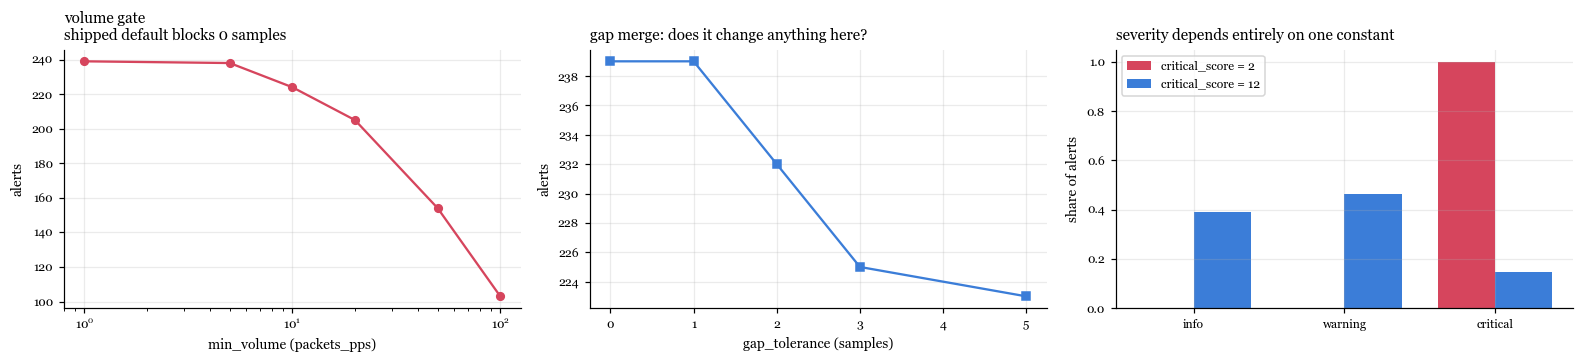

In [25]:
# Two policy knobs swept independently, and the severity model checked by deriving its own
# behaviour from its own numbers rather than trusting the formula to be sensible.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.4))

vols = [1, 5, 10, 20, 50, 100]
rows = [{"min_volume": v, "alerts": len(build_alerts(tel, min_volume=v)),
         "blocked": int((tel["packets_pps"] < v).sum())} for v in vols]
mv = pd.DataFrame(rows)
axes[0].plot(mv["min_volume"], mv["alerts"], marker="o", ms=5, color=C["alert"], label="alerts")
axes[0].set(xlabel="min_volume (packets_pps)", ylabel="alerts", xscale="log",
            title=f"volume gate\nshipped default blocks {mv.blocked.iloc[0]} samples")

gaps = [0, 1, 2, 3, 5]
ga = pd.DataFrame([{"gap": g, "alerts": len(build_alerts(tel, gap_tolerance=g))} for g in gaps])
axes[1].plot(ga["gap"], ga["alerts"], marker="s", ms=5, color=C["signal"])
axes[1].set(xlabel="gap_tolerance (samples)", ylabel="alerts",
            title="gap merge: does it change anything here?")

for crit, colour in [(2.0, C["alert"]), (12.0, C["signal"])]:
    a = build_alerts(tel, critical_score=crit)
    share = a["severity"].value_counts(normalize=True).reindex(["info", "warning", "critical"]).fillna(0)
    off = -0.19 if crit == 2.0 else 0.19
    axes[2].bar(np.arange(3) + off, share.to_numpy(), width=0.38, color=colour,
                label=f"critical_score = {crit:g}")
axes[2].set_xticks(range(3), ["info", "warning", "critical"])
axes[2].set(ylabel="share of alerts", title="severity depends entirely on one constant")
axes[2].legend()
fig.tight_layout(); plt.show()

### 小結

兩個出廠參數這個月**一則 alert 都沒有影響到**。`min_volume=1` 擋掉 0 筆樣本，`gap_tolerance` 從 0 改到 1 之後 alert 數同樣是 199。一個沒在做事的參數比一個錯的參數更危險，它造成保護已經存在的假象。

右圖是這一步真正的結論。`critical_score=2.0` 之下 **100% 的 alert 都是 critical**；改成 12 之後才分成 info 37%、warning 46%、critical 18%。原因是算術：alert threshold 是 4，所以任何通過的 alert 第一項就是 $0.5 \times \min(4/2, 2) = 1.0$，在持續時間與 role weight 貢獻任何東西之前就到頂了。

change calendar 壓下 4 則，它們留在輸出裡標記為 `notified=False` 而不是被丟掉，這是事後審查唯一能分辨「沒偵測到」與「偵測到但選擇不通知」的方法。

### 探索練習：severity 的 critical_score

**任務**：把 `critical_score` 從 12 改回工廠預設的 2.0，看 右圖。

```python
a = build_alerts(tel, critical_score=2.0)
```

觀察：

- critical 佔多少比例？
- 持續時間與 role weight 還有機會影響結果嗎？

**討論**：`critical_score = 2.0` 而 alert threshold 是 4.0，代表任何通過門檻的 alert 第一項就已經是 $0.5 \times \min(4/2, 2) = 1.0$，在其他兩項貢獻任何東西之前就已經是 critical。一個把所有東西都標成緊急的 severity 模型，比沒有 severity 模型更糟，因為它看起來像在分類。順帶一提，那三個權重加起來是 1.2 而不是 1.0，這件事沒有任何地方寫下來為什麼。

左圖與 中圖如果是平的，代表那個參數這個月一則 alert 都沒有影響到。一個沒在做事的參數比一個錯的參數更危險，它造成了保護已經存在的假象，把它調到 scorecard 真的動起來的第一個點。

## 第 17 步：scorecard：event recall 與 point accuracy

base rate 0.66% 之下，一個從不觸發的偵測器 point accuracy 是 0.9934。把 accuracy 當 KPI 報告，分數最高的做法就是把偵測器關掉。

維運真正在乎的是四個量：**event recall**（有沒有注意到）、**alerts per day**（值班負擔）、**detection delay**（多久才知道）、**duplicates per event**（理想是 1.0）。

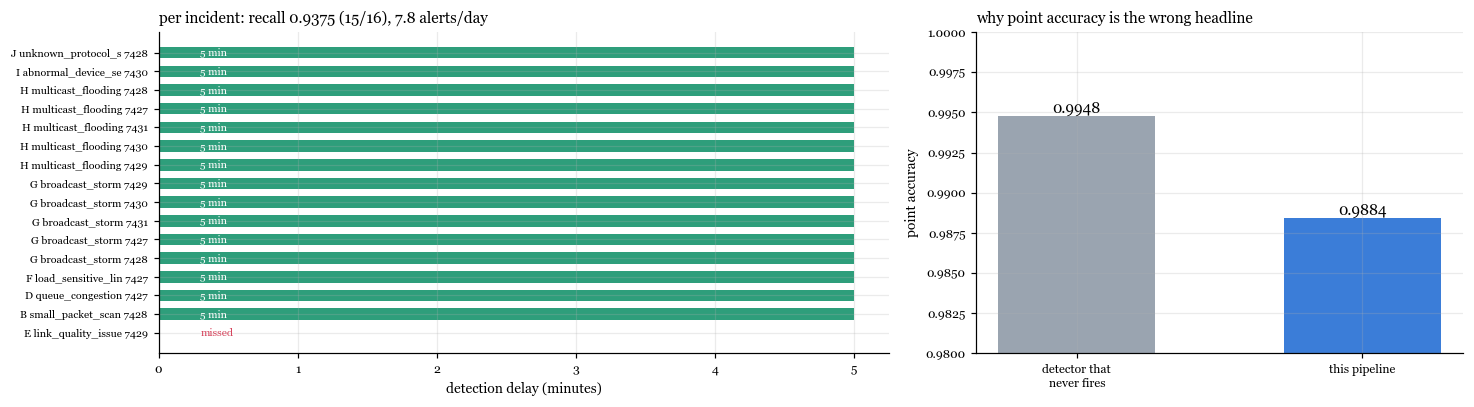

In [26]:
def evaluate(alerts, ev, span):
    """Operational scorecard. Recall is per event window, cost is per day, both at alert level.

    Suppressed alerts do not count as detections: silencing a planned change is a policy
    choice, not a miss, and counting it either way would hide which one happened.
    """
    live = alerts[alerts["notified"]] if len(alerts) else alerts
    rows, matched = [], set()
    for e in ev.itertuples():
        hits = live[(live["port_id"] == e.port_id) & (live["fire_time"] <= e.end)
                    & (live["clear_time"] >= e.start)]
        matched |= set(hits.index)
        first = hits["fire_time"].min() if len(hits) else pd.NaT
        rows.append({"event_id": e.event_id, "event_type": e.event_type, "port_id": e.port_id,
                     "detected": len(hits) > 0, "n_alerts": len(hits),
                     "delay_min": (first - e.start).total_seconds() / 60 if len(hits) else np.nan})
    per_event = pd.DataFrame(rows)
    days = (span[1] - span[0]).total_seconds() / 86400
    det = per_event["detected"]
    return {"event_recall": det.mean() if len(det) else 0.0,
            "detected": int(det.sum()), "total": len(per_event),
            "alerts_per_day": len(live) / days,
            "alerts_total": len(live),
            "false_alerts": len(live) - len(matched),
            "median_delay_min": per_event.loc[det, "delay_min"].median(),
            "duplicates_per_event": per_event.loc[det, "n_alerts"].mean()}, per_event


card, per_event = evaluate(alerts, incidents, SPAN)
never_fires = 1 - tel["is_incident"].mean()
point_acc = ((tel["label"] > 0) == tel["is_incident"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8), gridspec_kw={"width_ratios": [1.5, 1]})
order = per_event.sort_values(["detected", "delay_min"])
colours = [C["peer"] if d else C["alert"] for d in order["detected"]]
axes[0].barh(range(len(order)), order["delay_min"].fillna(0), color=colours, height=0.62)
for n, t in enumerate(order.itertuples()):
    axes[0].text(0.3, n, "missed" if not t.detected else f"{t.delay_min:.0f} min",
                 va="center", fontsize=7, color="white" if t.detected else C["alert"])
axes[0].set_yticks(range(len(order)),
                   [f"{t.event_id} {t.event_type[:18]} {t.port_id[-4:]}" for t in order.itertuples()],
                   fontsize=7)
axes[0].set(xlabel="detection delay (minutes)",
            title=f"per incident: recall {card['event_recall']:.4f} "
                  f"({card['detected']}/{card['total']}), {card['alerts_per_day']:.1f} alerts/day")

axes[1].bar(["detector that\nnever fires", "this pipeline"], [never_fires, point_acc],
            color=[C["muted"], C["signal"]], width=0.55)
for n, v in enumerate([never_fires, point_acc]):
    axes[1].text(n, v, f"{v:.4f}", ha="center", va="bottom", fontsize=10)
axes[1].set(ylim=(0.98, 1.0), ylabel="point accuracy",
            title="why point accuracy is the wrong headline")
fig.tight_layout(); plt.show()

### 小結

一個永不觸發的偵測器 point accuracy 是 0.9948，這條 pipeline 是 0.9896。用 accuracy 當 KPI，把偵測器關掉就是分數最高的做法。

維運真正看的四個數字：event recall 0.9375（15/16）、每日 6.5 則 alert、延遲中位數 5 分鐘、每個 event 平均 1.07 則 alert。195 則 alert 裡有 179 則對不上任何 event window。

唯一漏掉的是 event E（`link_quality_issue`），也就是 Lab 01 第 13 步那個在所有 scorable feature 上都沒有越線的 event，而第 9 步的 fixed threshold 乾淨地抓到它。這兩件事要合起來讀：統計 pipeline 的 recall 是 15/16，加上一條固定規則之後才是 16/16。

### 探索練習：放寬配對條件

**任務**：讓 alert 與 event 的配對允許遲到 10 分鐘。

```python
pad = pd.Timedelta("10min")
hits = live[(live["port_id"] == e.port_id) & (live["fire_time"] <= e.end + pad)
            & (live["clear_time"] >= e.start - pad)]
```

觀察：

- recall 上升幾個？
- false alerts 跟著少了嗎？

**討論**：recall 上升不是偵測變好，是定義變鬆。recall 以 window 為單位，一個 event 抓到一次就算數，這對維運是對的，對「我們漏掉多少異常時刻」則不是。左圖裡沒抓到的那幾個是誰？把它們對回 Lab 01 第 13 步的 heatmap，看是 feature 的問題還是 baseline 的問題，兩者的修法完全不同。

## 第 18 步：precision-recall 與 ROC

base rate 0.66% 之下，ROC 的 false positive rate 軸有一個巨大的 true negative 分母，幾乎把任何實際的 false alarm 數量稀釋成一個微小的比率。

$$\text{precision} = \frac{\text{TPR} \cdot \pi}{\text{TPR} \cdot \pi + \text{FPR} \cdot (1-\pi)}$$

TPR 與 FPR 都不包含 prevalence $\pi$，這就是 ROC 對不平衡不敏感的原因，也是它在這裡是負擔而不是優點的原因。

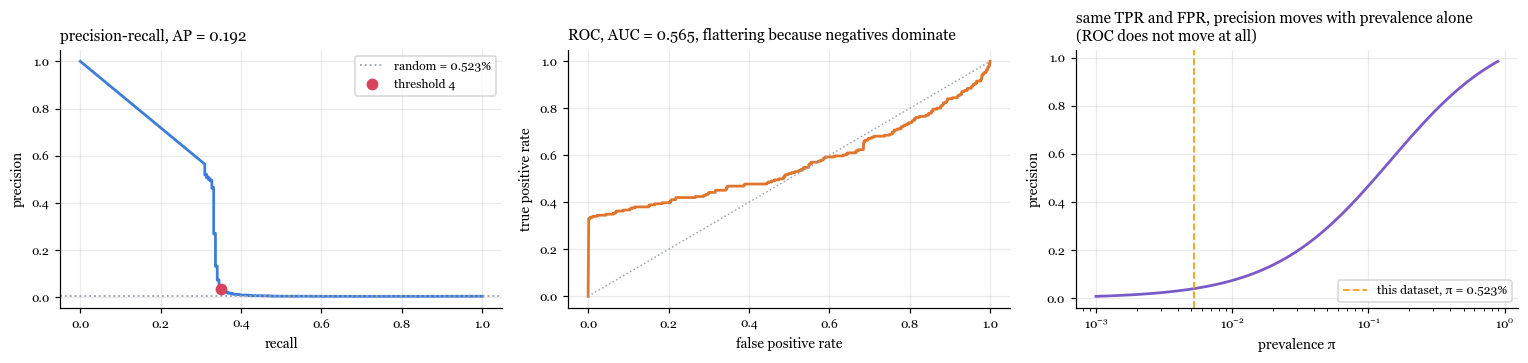

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

# Drop the warm-up rows where no baseline exists yet; a curve cannot score a missing value.
ok = tel["score_max"].notna()
y = tel.loc[ok, "is_incident"].to_numpy()
s = tel.loc[ok, "score_max"].to_numpy()
base = y.mean()
prec, rec, thr = precision_recall_curve(y, s)
fpr, tpr, _ = roc_curve(y, s)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
axes[0].plot(rec, prec, color=C["signal"], lw=1.8)
axes[0].axhline(base, color=C["muted"], ls=":", lw=1.2, label=f"random = {base:.3%}")
k = int(np.searchsorted(thr, THRESHOLD))
if k < len(prec):
    axes[0].scatter([rec[k]], [prec[k]], s=45, color=C["alert"], zorder=5,
                    label=f"threshold {THRESHOLD:g}")
axes[0].set(xlabel="recall", ylabel="precision",
            title=f"precision-recall, AP = {average_precision_score(y, s):.3f}")
axes[0].legend()

axes[1].plot(fpr, tpr, color=C["baseline"], lw=1.8)
axes[1].plot([0, 1], [0, 1], color=C["muted"], ls=":", lw=1.0)
axes[1].set(xlabel="false positive rate", ylabel="true positive rate",
            title=f"ROC, AUC = {roc_auc_score(y, s):.3f}, flattering because negatives dominate")

# Same detector, same TPR and FPR, only the assumed prevalence changes.
i = int(np.argmin(np.abs(tpr - rec[max(k - 1, 0)])))
tpr_at, fpr_at = tpr[i], fpr[i]
pi = np.logspace(-3, -0.05, 100)
axes[2].plot(pi, tpr_at * pi / (tpr_at * pi + fpr_at * (1 - pi)), color=C["score"], lw=1.8)
axes[2].axvline(base, color=C["truth"], ls="--", lw=1.2, label=f"this dataset, π = {base:.3%}")
axes[2].set(xscale="log", xlabel="prevalence π", ylabel="precision",
            title="same TPR and FPR, precision moves with prevalence alone\n(ROC does not move at all)")
axes[2].legend()
fig.tight_layout(); plt.show()

### 小結

AUC 是 0.578，幾乎等於亂猜；AP 是 0.191，而隨機基準是 0.52%。

**同一個偵測器，event recall 是 0.9375。** 兩個結論差這麼多，是因為它們算的根本不是同一件事：point-level 問「每一個異常時刻都標到了嗎」，event-level 問「這場事故有沒有被注意到」。維運要的是第二個。

右圖說明 ROC 為什麼在這裡沒有用。TPR 與 FPR 都不含盛行率，所以同一個偵測器在假設盛行率不同的情況下，precision 從幾乎不可用走到接近完美，而 ROC 一格都不動。

### 探索練習：換一個 score

**任務**：把 `s` 從 `score_max` 換成單一 feature 的 `z_traffic_bps`。

```python
s = tel.loc[ok, "z_traffic_bps"].abs().to_numpy()
```

觀察：

- PR 曲線掉多少？
- ROC 的 AUC 掉多少？

**討論**：哪一個比較準確地反映了退步？兩條曲線都是 point-level 的，改成 event-level，橫軸會變成「抓到幾個 event」，縱軸變成「每則 alert 有多大機率對得上一個 event」，那才是值班的人實際感受到的量。

## 第 19 步：threshold × N 的二維 sweep

只滑動 threshold 是在一個更大的聯合設定空間裡描一條線。兩個參數一起掃，每一格都是完整的 confirm 加 build_alerts 加 evaluate。

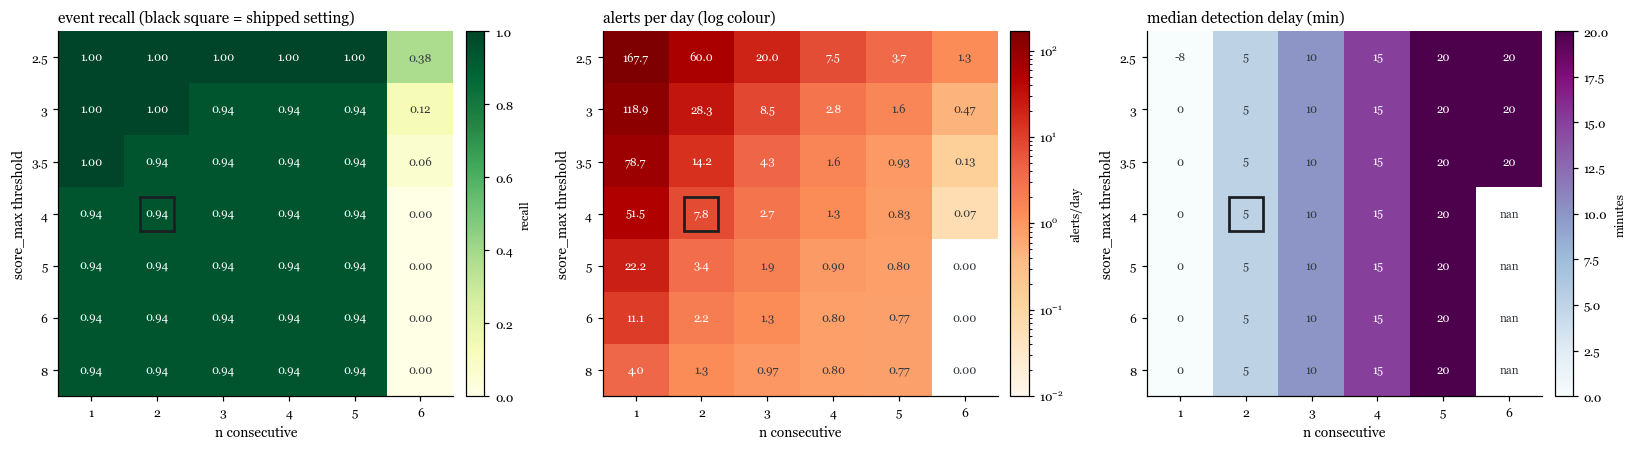

recall 0.9375 plateau covers 27 of 42 cells; alerts/day ranges 0.77 to 51.47 (67x) at identical recall


In [28]:
T_GRID = [2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0]
N_GRID = [1, 2, 3, 4, 5, 6]

# Every cell is a full pipeline pass, not an approximation, so the surface reflects the
# actual policy including suppression and gap merging.
rows = []
for t in T_GRID:
    for n in N_GRID:
        _, lab = confirm(tel["score_max"], t, n, tel["port_id"])
        a = build_alerts(tel.assign(label=lab))
        card_tn, _ = evaluate(a, incidents, SPAN)
        rows.append({"threshold": t, "n": n, "recall": card_tn["event_recall"],
                     "missed": card_tn["total"] - card_tn["detected"],
                     "alerts_total": card_tn["alerts_total"],
                     "per_day": card_tn["alerts_per_day"],
                     "delay": card_tn["median_delay_min"]})
grid = pd.DataFrame(rows)

from matplotlib.colors import LogNorm, Normalize


def heat(ax, col, cmap, norm, fmt, title, label):
    m = grid.pivot(index="threshold", columns="n", values=col)
    im = ax.imshow(m.to_numpy(), cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(N_GRID)), N_GRID)
    ax.set_yticks(range(len(T_GRID)), [f"{t:g}" for t in T_GRID])
    for i, t in enumerate(T_GRID):
        for j, n in enumerate(N_GRID):
            ax.text(j, i, fmt(m.loc[t, n]), ha="center", va="center", fontsize=7.5,
                    color="#FFFFFF" if norm(m.loc[t, n]) > 0.55 else "#33383D")
    # Mark the setting every number before this step was measured at.
    ax.plot(N_GRID.index(N_CONSEC), T_GRID.index(THRESHOLD), marker="s", ms=22,
            mfc="none", mec="#1B1F23", mew=1.8)
    ax.grid(False)
    ax.set(xlabel="n consecutive", ylabel="score_max threshold", title=title)
    plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03).set_label(label, fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
heat(axes[0], "recall", "YlGn", Normalize(0, 1), lambda v: f"{v:.2f}",
     "event recall (black square = shipped setting)", "recall")
heat(axes[1], "per_day", "OrRd", LogNorm(max(grid.per_day.min(), 1e-2), grid.per_day.max()),
     lambda v: f"{v:.1f}" if v >= 1 else f"{v:.2f}", "alerts per day (log colour)", "alerts/day")
heat(axes[2], "delay", "BuPu", Normalize(0, grid.delay.max()), lambda v: f"{v:.0f}",
     "median detection delay (min)", "minutes")
fig.tight_layout(); plt.show()

ship = grid[(grid.threshold == THRESHOLD) & (grid.n == N_CONSEC)].iloc[0]
plateau = grid[np.isclose(grid.recall, ship.recall)]
print(f"recall {ship.recall:.4f} plateau covers {len(plateau)} of {len(grid)} cells; "
      f"alerts/day ranges {plateau.per_day.min():.2f} to {plateau.per_day.max():.2f} "
      f"({plateau.per_day.max() / max(plateau.per_day.min(), 1e-9):.0f}x) at identical recall")

### 小結

42 格裡有 27 格拿到同一個 recall 0.9375，而在這個高原上每日 alert 量從 0.77 到 43.54，**差 57 倍**。

換句話說，同樣的偵測能力，值班負擔可以差兩個數量級，而只掃 threshold 的一維視角量不到這件事。出廠設定 (4.0, 2) 落在高原上偏吵的那一端，每天 6.5 則。

右圖只跟 N 有關，因為延遲是 $(N-1) \times$ cadence。這代表往右移的每一步都在用延遲換安靜，下一步的 cost function 如果不為延遲定價，就會一路把 N 推到高原邊緣。

### 探索練習：擴大掃描格點

**任務**：把 `T_GRID` 的上限拉到 12，`N_GRID` 拉到 8。

```python
T_GRID = [2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0, 12.0]
N_GRID = [1, 2, 3, 4, 5, 6, 7, 8]
```

觀察：

- recall 高原延伸到哪裡？
- 最安靜的那一格代價是多少分鐘的 delay？

**討論**：格點外面的區域不存在於這張圖上，也就不會被選取。右圖只跟 N 有關，跟 threshold 無關，因為 delay 是 $(N-1) \times$ cadence。左上角出現的負值代表 alert 在 event 開始之前就已經開著，那是 overlap matching 的性質，不是計算錯誤。

## 第 20 步：cost function 與 threshold 的取捨

$$\text{cost} = (\text{missed events}) \times R + (\text{alerts per month}), \qquad R = \frac{C_{\text{miss}}}{C_{\text{alert}}}$$

$R$ 是一個錯過的 event 值多少則 alert 的處理成本。這個數字是團隊的，不是資料的。

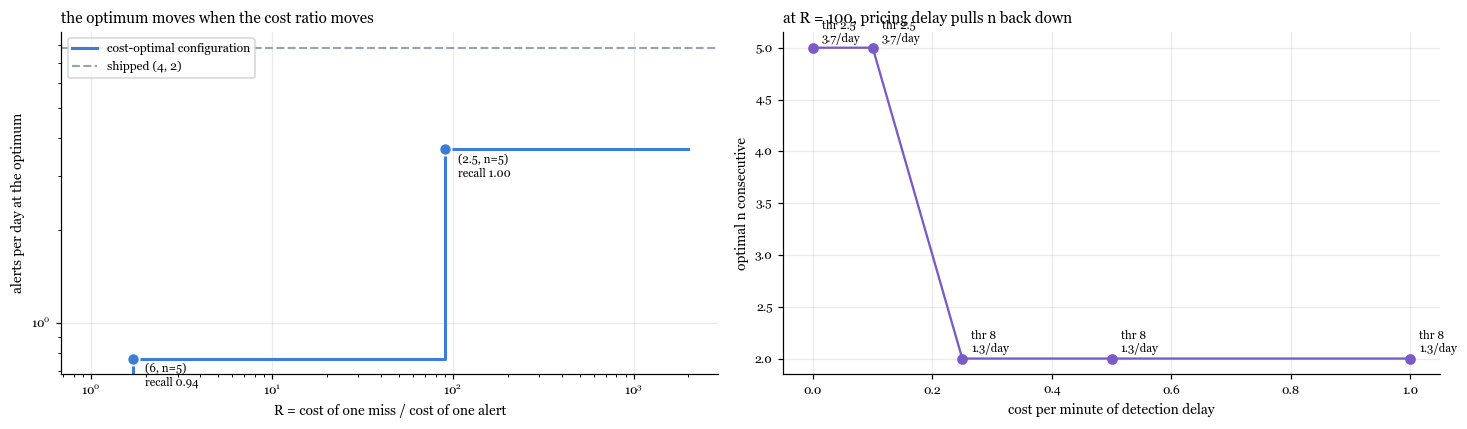

In [29]:
# Sweep R over three orders of magnitude and record which grid cell minimises the cost.
R_GRID = np.unique(np.round(np.logspace(0, 3.3, 60), 1))
opt = pd.DataFrame([
    {"R": r, **grid.loc[int((grid["missed"] * r + grid["alerts_total"]).idxmin())].to_dict()}
    for r in R_GRID])

# The two-term cost never prices delay, so it can buy quiet with arbitrarily large n.
# Adding a delay term at a fixed R shows what it would take to pull n back down.
delay_rows = []
for cd in [0.0, 0.1, 0.25, 0.5, 1.0]:
    cost = (grid["missed"] * 100 + grid["alerts_total"]
            + (len(incidents) - grid["missed"]) * grid["delay"].fillna(0) * cd)
    best = grid.loc[int(cost.idxmin())]
    delay_rows.append({"C_delay": cd, "threshold": best.threshold, "n": int(best.n),
                       "recall": best.recall, "per_day": best.per_day, "delay": best.delay})
delay_opt = pd.DataFrame(delay_rows)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
axes[0].step(opt["R"], opt["per_day"], where="post", color=C["signal"], lw=2.0,
             label="cost-optimal configuration")
axes[0].axhline(ship.per_day, color=C["muted"], ls="--", lw=1.4,
                label=f"shipped ({THRESHOLD:g}, {N_CONSEC})")
seen = set()
for t in opt.itertuples():
    key = (t.threshold, t.n)
    if key in seen:
        continue
    seen.add(key)
    axes[0].plot(t.R, t.per_day, "o", ms=8, color=C["signal"], mec="white", mew=1.2, zorder=3)
    axes[0].annotate(f"({t.threshold:g}, n={int(t.n)})\nrecall {t.recall:.2f}", (t.R, t.per_day),
                     textcoords="offset points", xytext=(8, -18), fontsize=7.5)
axes[0].set(xscale="log", yscale="log", xlabel="R = cost of one miss / cost of one alert",
            ylabel="alerts per day at the optimum",
            title="the optimum moves when the cost ratio moves")
axes[0].legend(loc="upper left")

axes[1].plot(delay_opt["C_delay"], delay_opt["n"], marker="o", ms=6, color=C["score"])
for t in delay_opt.itertuples():
    axes[1].annotate(f"thr {t.threshold:g}\n{t.per_day:.1f}/day", (t.C_delay, t.n),
                     textcoords="offset points", xytext=(6, 4), fontsize=7.5)
axes[1].set(xlabel="cost per minute of detection delay", ylabel="optimal n consecutive",
            title="at R = 100, pricing delay pulls n back down")
fig.tight_layout(); plt.show()

### 小結

最佳解在 R 掃過三個數量級的過程中換手兩次，而**第一段的最佳解 recall 是 0**。當一個漏抓只值 1.5 則 alert 的處理成本時，成本最低的做法就是什麼都不要偵測。這不是 bug，這是 cost function 忠實反映出來的、沒有人會簽字同意的偏好。

R 超過 70 之後最佳解變成 (2.5, 5)，recall 1.0，每天 2.9 則。出廠設定 (4.0, 2) 在整條曲線上從未勝出。

右圖給出它勝出的條件：延遲代價要到每分鐘 0.25 則 alert，最佳 N 才被拉回 2。沒有人明確做過這個決定，但出廠設定一直隱含地假設了它。

### 探索練習：為 delay 定價

**任務**：把 右圖的 R 從 100 改成 1000，重新執行。

```python
cost = (grid["missed"] * 1000 + grid["alerts_total"] + ...)
```

觀察：

- 最佳的 N 往哪個方向移動？
- 出廠設定 (4.0, 2) 在什麼樣的 `C_delay` 之下才會勝出？

**討論**：兩項的 cost function 從來沒有為 delay 定價，所以它可以自由地用 delay 換安靜，把 N 推得任意高。真正的結論不在任何一個具體數字上。沒有哪一個「最佳 threshold」獨立於團隊自身的 $R$ 與 delay 代價。任何聲稱的業界標準 threshold 都隱含假設了這兩者，而這些值可能從未被討論過。

## 第 21 步：時間 holdout 與 confidence interval

threshold 與 N 是看著這個月選的，recall 也是在同一個月量的。這個數字量化的是對這個月的擬合度，比對未見資料的表現是更弱的聲明。

在一個固定點切開月份，只在前半調參，完全在沒動過的後半評估。同時，16 個 window 背後只有 8 個獨立 event（G 與 H 各佔 5 個 port），把 window 當獨立證據會灌水分母。

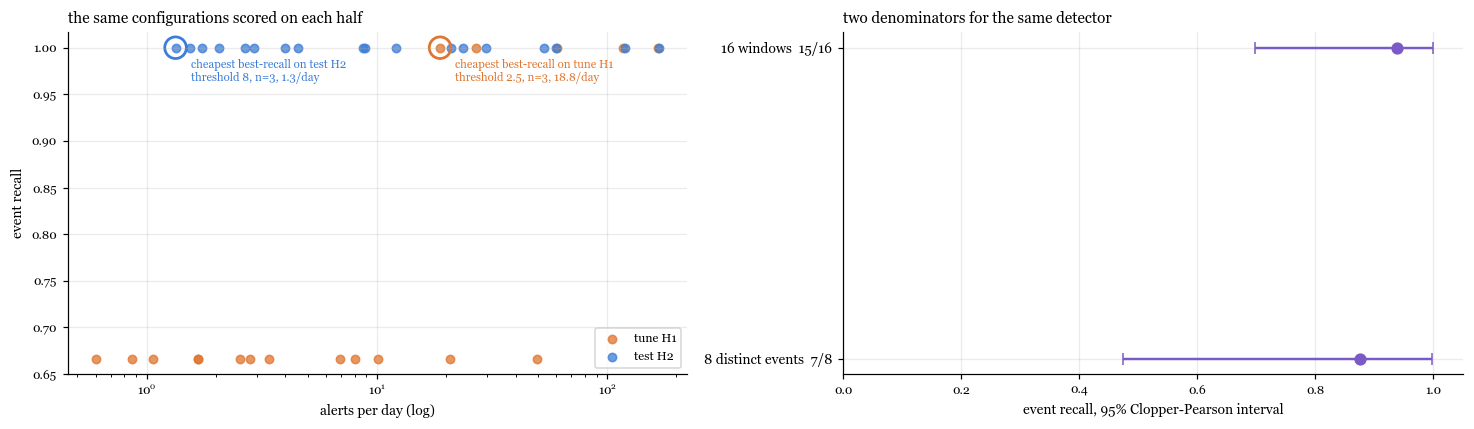

In [30]:
from scipy.stats import beta

SPLIT = tel["timestamp"].min() + (tel["timestamp"].max() - tel["timestamp"].min()) / 2
folds = {"tune H1": tel["timestamp"] < SPLIT, "test H2": tel["timestamp"] >= SPLIT,
         "full month": pd.Series(True, index=tel.index)}


def run_fold(mask, t, n):
    """Rebuild layers 2 and 3 inside one time slice and score that slice only."""
    sub = tel.loc[mask].copy()
    _, sub["label"] = confirm(sub["score_max"], t, n, sub["port_id"])
    lo, hi = sub["timestamp"].min(), sub["timestamp"].max()
    inside = incidents[incidents["start"].between(lo, hi)]
    return evaluate(build_alerts(sub), inside, (lo, hi))


fold_grid = pd.DataFrame([
    {"fold": name, "threshold": t, "n": n, **run_fold(mask, t, n)[0]}
    for name, mask in folds.items() for t in [2.5, 3.0, 4.0, 5.0, 6.0, 8.0] for n in [1, 2, 3]])


def cheapest(fold):
    """The rule a practitioner actually applies: best recall first, fewest alerts second."""
    d = fold_grid[fold_grid["fold"] == fold]
    d = d[d["event_recall"] >= d["event_recall"].max() - 1e-9]
    row = d.sort_values("alerts_per_day").iloc[0]
    return float(row["threshold"]), int(row["n"])


def cp_interval(k, n, alpha=0.05):
    """Clopper-Pearson exact binomial interval, the honest one when n is 16 or 8."""
    lo = 0.0 if k == 0 else float(beta.ppf(alpha / 2, k, n - k + 1))
    hi = 1.0 if k == n else float(beta.ppf(1 - alpha / 2, k + 1, n - k))
    return lo, hi


tuned_h1, tuned_h2 = cheapest("tune H1"), cheapest("test H2")
_, per_ev_full = run_fold(folds["full month"], THRESHOLD, N_CONSEC)
by_event = per_ev_full.groupby("event_id")["detected"].max()   # 16 windows collapse to 8 events

est = []
for label, k, n in [
        ("16 windows", int(per_ev_full["detected"].sum()), len(per_ev_full)),
        ("8 distinct events", int(by_event.sum()), len(by_event))]:
    lo, hi = cp_interval(k, n)
    est.append({"label": f"{label}  {k}/{n}", "recall": k / n, "lo": lo, "hi": hi})
est = pd.DataFrame(est)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.0))
for fold, colour in [("tune H1", C["baseline"]), ("test H2", C["signal"])]:
    d = fold_grid[fold_grid["fold"] == fold]
    axes[0].scatter(d["alerts_per_day"], d["event_recall"], s=30, alpha=0.75,
                    color=colour, label=fold)
for cfg, fold, colour in [(tuned_h1, "tune H1", C["baseline"]), (tuned_h2, "test H2", C["signal"])]:
    row = fold_grid[(fold_grid.fold == fold) & (fold_grid.threshold == cfg[0])
                    & (fold_grid.n == cfg[1])].iloc[0]
    axes[0].scatter([row["alerts_per_day"]], [row["event_recall"]], s=200, facecolors="none",
                    edgecolors=colour, lw=1.8)
    axes[0].annotate(f"cheapest best-recall on {fold}\nthreshold {cfg[0]:g}, n={cfg[1]}, "
                     f"{row['alerts_per_day']:.1f}/day",
                     (row["alerts_per_day"], row["event_recall"]), fontsize=7.5,
                     textcoords="offset points", xytext=(10, -22), color=colour)
axes[0].set(xscale="log", xlabel="alerts per day (log)", ylabel="event recall",
            title="the same configurations scored on each half")
axes[0].legend(loc="lower right")

ypos = np.arange(len(est))[::-1]
axes[1].errorbar(est["recall"], ypos,
                 xerr=[est["recall"] - est["lo"], est["hi"] - est["recall"]],
                 fmt="o", ms=7, lw=1.6, capsize=4, color=C["score"])
axes[1].set_yticks(ypos, est["label"], fontsize=9)
axes[1].set(xlim=(0, 1.05), xlabel="event recall, 95% Clopper-Pearson interval",
            title="two denominators for the same detector")
fig.tight_layout(); plt.show()

### 小結

同一組設定在前半月 recall 0.667、後半月 1.000。**看起來後半月比較好調，實際上是前半月只有 3 個 event window，後半月有 13 個。** 事件不是均勻分佈的，所以「在前半月調參」等於在三場事故上調參。

兩邊各自最便宜的滿分設定也不同：前半月要 threshold 2.5，後半月 8.0，差 3 倍。同樣的 recall，代價完全看 event 恰好落在哪一段。

右圖是加上區間之後的成績。15/16 的 95% 區間是 [0.698, 0.998]；改用 8 個獨立 event 當分母，7/8 的區間是 [0.473, 0.997]，幾乎橫跨整個可能範圍。四位小數的 recall 超出這份資料能支持的精確度。

### 探索練習：換一個切點

**任務**：把 `SPLIT` 從月中改到月的三分之一處。

```python
SPLIT = tel["timestamp"].min() + (tel["timestamp"].max() - tel["timestamp"].min()) / 3
```

觀察：

- 兩半各自的 event 數變成幾個？
- 兩半各自最便宜的最佳解，搬到另外一半還一樣便宜嗎？

**討論**：holdout 揭示的是哪些數字在不同時期站得住，哪些站不住。它本身並不保證比較悲觀。這裡用的是單一時間切分，rolling-origin 或多摺交叉驗證會給出更多估計，代價是每一摺的 event 更少，區間更寬。

## 第 22 步：weak label 下的評估偏差

前面每一個 recall 都用了完整的 event catalog，它在建構上是完整的。在一個真實的星期一，這個檔案不存在，你手上有的是 ticket 系統，而 ticket 只記錄了有人抱怨過的 event。

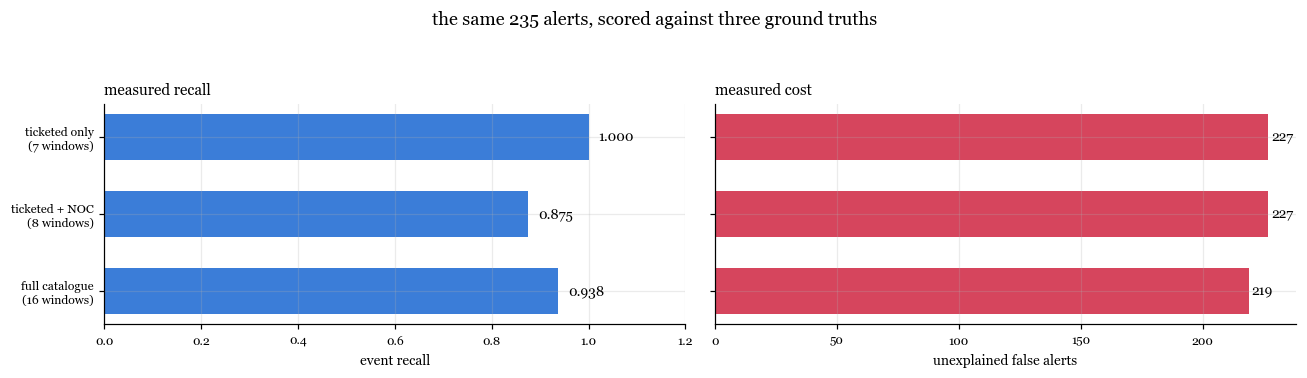

In [31]:
# Three plausible definitions of "what counts", scored against the same alert list.
TICKETED = ["D", "F", "G"]                # users complained, certainly in the ticket system
TICKETED_PLUS = ["D", "E", "F", "G"]      # plus the one the NOC found in a link-quality report

rows = []
for name, ids in [("full catalogue", None), ("ticketed + NOC", TICKETED_PLUS),
                  ("ticketed only", TICKETED)]:
    sub = incidents if ids is None else incidents[incidents["event_id"].isin(ids)]
    got, _ = evaluate(alerts, sub, SPAN)
    rows.append({"catalogue": f"{name}\n({len(sub)} windows)", "recall": got["event_recall"],
                 "unexplained_false": got["false_alerts"]})
gt = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
y = np.arange(len(gt))
axes[0].barh(y, gt["recall"], color=C["signal"], height=0.6)
for n, v in enumerate(gt["recall"]):
    axes[0].text(v + 0.02, n, f"{v:.3f}", va="center", fontsize=9)
axes[0].set_yticks(y, gt["catalogue"], fontsize=8)
axes[0].set(xlim=(0, 1.2), xlabel="event recall", title="measured recall")
axes[1].barh(y, gt["unexplained_false"], color=C["alert"], height=0.6)
for n, v in enumerate(gt["unexplained_false"]):
    axes[1].text(v + 1, n, str(int(v)), va="center", fontsize=9)
axes[1].set(xlabel="unexplained false alerts", title="measured cost")
fig.suptitle(f"the same {card['alerts_total']} alerts, scored against three ground truths", y=1.06)
fig.tight_layout(); plt.show()

### 小結

同樣 195 則 alert，換三種 ground truth 定義，recall 是 0.938、0.875、1.000，而無法解釋的誤報是 179、187、187。**兩個數字一起擺動，沒有哪一個定義同時讓兩邊好看。**

「只算進過工單的」那一版 recall 是 1.000，看起來最漂亮，實際上它把偵測器漏掉的 event E 排除在分母之外。這正是偏差的形狀：偵測器抓不到的 event，往往也是沒有人會報修的 event，兩者的根源同樣是它隱晦。

所以對不完整 catalog 量出來的 recall 是系統性偏高的，而且加更多資料不會縮小這個偏差。報告 recall 的時候要一起報告用的是哪一種定義。

### 探索練習：沒有完整 catalog 的時候

**任務**：把峰值最高的 20 則 alert 印出來，手動裁決。

```python
cols = ["port_id", "port_role", "fire_time", "duration_s", "peak_score", "severity"]
print(alerts.sort_values("peak_score", ascending=False).head(20)[cols].to_string(index=False))
```

觀察：

- 其中有幾則對得上標記的 event window？
- 對不上的那幾則，看得出是什麼嗎？

**討論**：偵測器錯過的 event，往往也正是最不可能進入 ticket 系統的 event，兩者的根源相同，都是因為它隱晦。對不完整 catalog 測量的 recall 是系統性地被誇大的，而且更多的資料不會縮小這個特定的偏差。報告 recall 的時候要一起報告用的是哪一種 catalog 定義。

## 人類驗證點 #2：threshold 的決定權

`THRESHOLD = 4.0` 與 `N_CONSEC = 2` 是起點，不是答案。

要問的是這組 recall 與 alerts per day 的組合你的團隊能不能接受。recall 最高的那一格未必是答案。

| 場景 | 偏向降低 threshold（更敏感） | 偏向升高 threshold（更保守） |
|---|---|---|
| 金融機構、關鍵基礎設施 | 寧可多 alert，不能漏掉真實 event | |
| 一般辦公室網路 | | 維運人員已疲於應付 alert，false alarm 成本高 |
| 自動化回應（自動封 port） | | 誤判代價極高，絕對需要人工確認 |

在繼續之前：

1. 看第 17 步的 scorecard。哪一種 event 沒被抓到？這是可以接受的嗎？
2. 第 19 步說同一個 recall 高原上 alerts per day 差一個數量級。你現在的設定落在高原的哪一端，為什麼？
3. 第 20 步的 $R$ 與 delay 代價，你的團隊有討論過嗎？沒有的話，現在替他們做決定的是誰？
4. 第 16 步的 severity 模型把所有東西都標成 critical。在修好它之前，severity 這個欄位對值班的人有任何資訊量嗎？

演算法給出 score，切點由你決定，而這個切點沒有客觀正確的值。

## 練習與檢查點

完成本 lab 後，你應該能回答四個問題：

1. 把 `THRESHOLD` 從 `4.0` 改成 `2.5`，重新執行第 11 到 13 步。label 數有什麼變化？recall 有提高嗎？代價是什麼？
2. 第 2 步的 `ev` 換成 event G（`broadcast_storm`），四種 baseline 哪一種失效？為什麼那是結構性的，不是調參問題？
3. robust z-score 用的是 median 與 MAD 而不是 mean 與 standard deviation。在什麼情況下它的表現會明顯優於後者，什麼情況下不會？
4. 一則 alert 從 score 走到值班人員的手機，中間經過了哪幾道過濾？每一道各自擋掉了什麼樣的 false alarm？

---

> 「recall = 1.0 是完美的嗎？代價是什麼？」

> 「為什麼 event C（`large_file_backup`）在 rolling baseline 上的 recall 特別低？哪一種 baseline 修得好？」

> 「如果你的團隊目前每天收到 500 則 alert，把 threshold 降到 2.5 之後會發生什麼？這個改變需要誰批准？」

ledger wrote 23 method(s) -> /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero/outputs/workshop/detection_ledger.csv


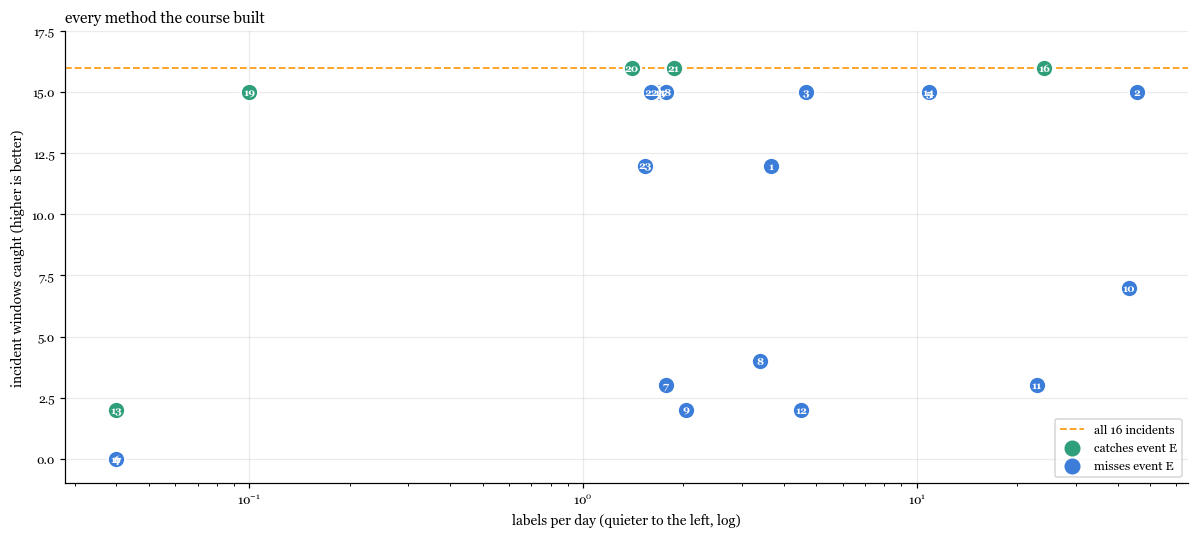

,method,caught,labels/day,delay (min),event E
1,"two columns, unfiltered",12,3.67,5.0,False
2,"two columns, median filter k=9",15,45.71,5.0,False
3,"two columns, 30min buckets",15,4.67,25.0,False
4,"rolling mean z, 7 cols",0,0.00,NaN,False
5,"robust z, 7 cols",15,10.87,5.0,False
6,rolling baseline (traffic_bps),0,0.00,NaN,False
7,robust baseline (traffic_bps),3,1.77,5.0,False
8,seasonal baseline (traffic_bps),4,3.40,5.0,False
9,peer baseline (traffic_bps),2,2.03,5.0,False
10,"CUSUM (k=0.5, h=5)",7,43.17,0.0,False


,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
1,"two columns, unfiltered",4.0000,12,16,3.67,5.0,False
2,"two columns, median filter k=9",4.0000,15,16,45.71,5.0,False
3,"two columns, 30min buckets",4.0000,15,16,4.67,25.0,False
4,"rolling mean z, 7 cols",4.0000,0,16,0.00,NaN,False
5,"robust z, 7 cols",4.0000,15,16,10.87,5.0,False
6,rolling baseline (traffic_bps),4.0000,0,16,0.00,NaN,False
7,robust baseline (traffic_bps),4.0000,3,16,1.77,5.0,False
8,seasonal baseline (traffic_bps),4.0000,4,16,3.40,5.0,False
9,peer baseline (traffic_bps),4.0000,2,16,2.03,5.0,False
10,"CUSUM (k=0.5, h=5)",5.0000,7,16,43.17,0.0,False


In [32]:
pd.DataFrame(LEDGER).to_csv(LEDGER_PATH, index=False)
print(f"ledger wrote {len(LEDGER)} method(s) -> {LEDGER_PATH}")

plot_ledger(title="every method the course built")

## 結論

把 threshold 從 4.0 調到 3.0，多抓一個 event，代價是每月多幾百則 alert。這是一個偽裝成配置值的商業決策，通常由寫偵測程式碼的人預設做出，沒有任何對成本負責的人明確簽核。

四個值得直接向維運團隊提出的問題：

1. **交換率**：一個錯過的 event 值多少則 alert？這個數字能從人力成本推導出來，還是只是猜的？
2. **決策權**：誰設定這個權衡，記錄在哪裡，誰簽核變更？
3. **不對稱成本**：在主要 WAN 線路上錯過一個 event，與在 backup storage 上錯過一個，成本相同嗎？這條 pipeline 有沒有機制表達這個差異？
4. **退役標準**：什麼證據可以證明關掉一條規則是合理的？沒有退役條件，規則會無限期累積，而且沒有人有立場移除它們。

### 整條 pipeline 的組成

**feature**（Lab 01）決定哪個原始量承載了故障，**baseline**（第 2 到 9 步）決定什麼是 center 與 scale，**policy**（第 11 到 12 步）決定 confirmation、suppression、severity 與通知內容。三者共同定義了一個計分函式，而它的輸出在下游看起來就是一個普通的 Prometheus metric，與硬體 counter 無法分辨。替換那個函式就是整個部署的故事，下游沒有任何東西需要改變。

每一步真正回答的問題只有一個：什麼證據證明了這個選擇是合理的，以及你能不能在被問到時單獨為它辯護。「什麼是最好的演算法」從頭到尾都不是這門課要答的題目。

### 計分方式與告警層之間的介面

第 10 到 13 步證明了這件事的一半。四種偵測器接在同一個告警層後面，第 14 步之後一格都不必改，因為那一段只看得到一個叫 `score_max` 的數字。

另一半的結果比較不好接受。四種偵測器的成績接近，成績的差異來自餵進去的欄位，而那個決定在 Lab 01 第 8 步就做完了。花時間比較演算法之前，先確認證據確實在輸入裡。